In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
from deap import gp
from gp.deap_gp import setup_pset
from gp.gp_generalise import infer_output
import matplotlib.pyplot as plt
from gp import deap_gp


In [8]:
#Functions to generate input samples, functions, output, and to infer with GP

def create_input_samples(numInputParameters, parameterRange=(0, 100), distinctInputSet=None, tableLength=10, random_seed=42):
    np.random.seed(random_seed)
    if distinctInputSet:
        df = pd.DataFrame()
        for i in range(numInputParameters):
            df[f'i{i}']=np.random.choice(distinctInputSet, size=tableLength)
            reg = np.zeros_like(df[f'i{i}'])
            reg[0] = np.random.choice(distinctInputSet)
            reg[1:] = df[f'i{i}'][:-1].values
            df[f'r{i}'] = reg 
    else:
        df = pd.DataFrame()
        for i in range(numInputParameters):
            df[f'i{i}']=np.random.randint(*parameterRange, size=tableLength)
            reg = np.zeros_like(df[f'i{i}'])
            reg[0] = np.random.randint(*parameterRange)
            reg[1:] = df[f'i{i}'][:-1].values
            df[f'r{i}'] = reg
    df = df[[c for c in df.columns if c.startswith('i')] + [c for c in df.columns if c.startswith('r')]]
    return df

def get_true_function_output(trueFunction, df):
    # build a pset with a dummy output column so arg names are renamed to df columns
    # add an output register to the dataframe 
    regs = df.columns.tolist()
    regs = [r for r in regs if r.startswith('r')]
    regsnums = [int(r[1:]) for r in regs]
    max_reg_num = max(regsnums) if regsnums else -1
    df[f'r{max_reg_num + 1}'] = np.zeros((len(df),), dtype=int)
    #add randomvalue to the first row of the output register to ensure it's not all zeros if the true function uses it
    # df.at[0, f'r{max_reg_num + 1}'] = np.random.randint(1,100)

    # compile the true function and apply it to the dataframe to get the output column

    df['o'] = np.zeros_like(df[f'r{max_reg_num + 1}'])
    pset = deap_gp.setup_pset(df)
    tree = gp.PrimitiveTree.from_string(trueFunction, pset)
    trueFunctionCompiled = gp.compile(tree, pset)
    if f'r{max_reg_num + 1}' not in trueFunction:
        df['o'] = df.drop(columns='o').apply(lambda row: trueFunctionCompiled(**row.to_dict()), axis=1)
        df.loc[1:, f'r{max_reg_num + 1}'] = df['o'][:-1].values
    else:
        for idx in df.index:
            if idx > 0:
                df.at[idx, f'r{max_reg_num + 1}'] = df.at[idx-1, 'o']
            row = df.loc[idx, df.drop(columns='o').columns]   
            df.at[idx, 'o'] = trueFunctionCompiled(**row.to_dict())
    
    # reorder columns to have inputs, then registers, then output
    df = df[[c for c in df.columns if c.startswith('i')] + [c for c in df.columns if c.startswith('r')] + ['o']]
    return df

def setFunction(parameters, complexity, constantProb=0.3, maxConstant=10, random_seed=42):
    np.random.seed(random_seed)
    regs = parameters.copy()
    regs = [r for r in regs if r.startswith('r')]
    regsnums = [int(r[1:]) for r in regs]
    max_reg_num = max(regsnums) if regsnums else -1
    parameters.append(f'r{max_reg_num + 1}') # add output register as a parameter for the function to use
    ops = ['add', 'sub', 'mul']
    constantProb = 1/(len(parameters)+1)
    u = np.random.random_sample()
    if u < constantProb:
        param1 = str(np.random.randint(1, maxConstant + 1))
    else:
        param1 = np.random.choice(parameters)

    if complexity <= 1:
        if complexity == 0:
            ops = ['add', 'sub']
        else:
            parameters = [p for p in parameters if p != param1]
        param2 = np.random.choice(parameters)
        op = np.random.choice(ops)
        return op + "(" + param1 + "," + param2 + ")"
    else:
        parameters = [p for p in parameters if p != f'r{max_reg_num + 1}'] 
        func = setFunction(parameters, complexity-1, constantProb, maxConstant)
        op = np.random.choice(ops)
        return op + "(" + param1 + "," + func + ")"

def setFunctionLinear(parameters, depth, maxCoeff=10, random_seed=42):
    ops = ['add', 'sub', 'mul']
    expr = ""
    np.random.seed(random_seed)
    while depth > 0:
        op = np.random.choice(ops)
        param = np.random.choice(parameters)
        if op == 'mul':
            coeff = np.random.randint(1, maxCoeff + 1)
            plusMinus = np.random.choice(['', '-'])
            newexpr = plusMinus + str(coeff) + "*" + param
        else:
            param1 = np.random.choice(parameters)
            param2 = np.random.choice(parameters)
            newexpr = param1 + op + param2
            depth -= 1
        if expr == "":
            expr = newexpr
        else:
            expr = expr + "+" + newexpr
    return expr

def infer_w_gp(df, ngen=100, random_seed=42):
    tmp = df.drop(columns=['o']).copy()
    pset = deap_gp.setup_pset(df)
    inferredFuncStr = infer_output(df, ngen=ngen, random_seed=random_seed)
    tree = gp.PrimitiveTree.from_string(inferredFuncStr, pset)
    inferredFunctionCompiled = gp.compile(tree, pset)
    df['inferred'] = tmp.apply(lambda row: inferredFunctionCompiled(**row.to_dict()), axis=1)
    return inferredFuncStr, df

In [ ]:
# Parameters for data generation and inference
sampledFuncs = 3
max_table_length = 80
tableLength = np.arange(20, max_table_length+1, 20)
numGenerations = [100, 200]
seedsForTable = np.arange(sampledFuncs)
seedsForGP = [0, 1, 2, 3, 4, 6, 7]
complexities = [1, 2, 3]
linear = False
numInputParameters = 2
parameterRange = (0, 100)


# Parameters for data generation and inference
# sampledFuncs = 1
# max_table_length = 40
# tableLength = np.arange(20, max_table_length+1, 20)
# numGenerations = [200]
# seedsForTable = np.arange(sampledFuncs)
# seedsForGP = [0]
# complexities = [1, 2]
# linear = False
# numInputParameters = 2
# parameterRange = (0, 10)

In [17]:
# DataFrame to store results of inferred functions for each complexity, tableLength, numGenerations combination
inferredFuncs = pd.DataFrame(columns=['complexity', 'trueFunction', 'seed', 'tableLength', 'numGenerations', 'inferredFunc'])
dfs = {}

totalRuns = len(complexities) * sampledFuncs * len(seedsForGP) * len(tableLength) * len(numGenerations)
currentRun = 0
for complexity in complexities:
    for s in seedsForTable:
        #Create input samples
        complete_df = create_input_samples(numInputParameters=numInputParameters, parameterRange=parameterRange, tableLength=max_table_length, random_seed=s)
        #Define true function and output samples
        if linear:
            trueFunction = setFunctionLinear([d for d in complete_df.columns], complexity, random_seed=s)
        else:
            trueFunction = setFunction([d for d in complete_df.columns], complexity, random_seed=s)
        print(f"True function: {trueFunction}")
        complete_df = get_true_function_output(trueFunction, complete_df)
        dfs[trueFunction] = complete_df
        complete_df['inferred'] = np.zeros(len(complete_df))
        for seed in seedsForGP:
            for i, t in enumerate(tableLength):
                df = complete_df.head(t).copy()
                for j, g in enumerate(numGenerations):
                    func, df = infer_w_gp(df.drop(columns=['inferred']), ngen=g, random_seed=seed)
                    inferredFuncs = pd.concat([inferredFuncs, pd.DataFrame({'complexity': [complexity], 'trueFunction': [trueFunction], 'seed': [seed], 'tableLength': [t], 'numGenerations': [g], 'inferredFunc': [func]})], ignore_index=True)
                    print(f"Completed run {currentRun + 1} of {totalRuns}")
                    currentRun += 1
            

True function: sub(i0,r2)
inferred output function:  add(i0, mul(-1, r2))
Completed run 1 of 4
inferred output function:  add(i0, mul(-1, r2))
Completed run 2 of 4
True function: add(i0,mul(r2,r0))
inferred output function:  add(mul(r0, r2), i0)
Completed run 3 of 4
inferred output function:  add(mul(r0, r2), i0)
Completed run 4 of 4


In [22]:
# Analyze errors and correlations to inputs of inferred functions

errorAnalysis = pd.DataFrame(columns=['complexity', 'tableLength', 'numGenerations', 'AccurateInferenceRate', 'ConstantErrorRate', 'OneHighCorrelationRate', 'MoreHighCorrelationsRate'])

for complexity in complexities:
    for t in tableLength:
        for g in numGenerations:
            subset = inferredFuncs[(inferredFuncs['complexity'] == complexity) & (inferredFuncs['tableLength'] == t) & (inferredFuncs['numGenerations'] == g)]
            meanAccurateInferenceCount = 0
            meanConstantErrorCount = 0
            meanOneHighCorrelationCount = 0
            meanTwoHighCorrelationsCount = 0
            meanMoreHighCorrelationsCount = 0
            for trueFunc in subset['trueFunction'].unique():
                subForFunc = subset[subset['trueFunction'] == trueFunc]
                accurateInferenceCount = 0
                constantErrorCount = 0
                oneHighCorrelationCount = 0
                twoHighCorrelationsCount = 0
                moreHighCorrelationsCount = 0
                trueOutput = dfs[trueFunc]['o'].head(t)
                for index, row in subForFunc.iterrows():
                    trueFunc = row['trueFunction']
                    inferredFunc = row['inferredFunc']
                    df = dfs[trueFunc].drop(columns=['inferred']).head(t).copy()
                    pset = setup_pset(df)
                    #treeTrue = gp.PrimitiveTree.from_string(trueFunc, pset)
                    treeInferred = gp.PrimitiveTree.from_string(inferredFunc, pset)
                    #funcTrueCompiled = gp.compile(treeTrue, pset)
                    funcInferredCompiled = gp.compile(treeInferred, pset)
                    #df['trueOutput'] = df.drop(columns=['o']).apply(lambda row: funcTrueCompiled(**row.to_dict()), axis=1)
                    df['inferredOutput'] = df.drop(columns=['o']).apply(lambda row: funcInferredCompiled(**row.to_dict()), axis=1)
                    error = trueOutput - df['inferredOutput']
                    if np.all(error == 0):
                        accurateInferenceCount += 1
                    elif np.all(error == error.iloc[0]):
                        constantErrorCount += 1
                    else:
                        for col in df.columns:
                            correlations = []
                            if col.startswith('i') or col.startswith('r'):
                                corr = np.corrcoef(df[col], error)[0, 1]
                                correlations.append(abs(corr))
                        threshold = max(correlations)*2/3
                        countHighCorrelation = sum(1 for c in correlations if c >= threshold)
                        if countHighCorrelation == 1:
                            oneHighCorrelationCount += 1
                        elif countHighCorrelation >= 2:
                            moreHighCorrelationsCount += 1
                        else:
                            pass
                totalCount = len(subForFunc)
                accurateInferenceRate = accurateInferenceCount / totalCount if totalCount > 0 else np.nan
                constantErrorRate = constantErrorCount / totalCount if totalCount > 0 else np.nan
                oneHighCorrelationRate = oneHighCorrelationCount / totalCount if totalCount > 0 else np.nan
                moreHighCorrelationsRate = moreHighCorrelationsCount / totalCount if totalCount > 0 else np.nan
        
                meanAccurateInferenceCount += accurateInferenceRate
                meanConstantErrorCount += constantErrorRate
                meanOneHighCorrelationCount += oneHighCorrelationRate
                meanMoreHighCorrelationsCount += moreHighCorrelationsRate
            sampledFuncCount = len(subset['trueFunction'].unique())
            meanAccurateInferenceRate = meanAccurateInferenceCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanConstantErrorRate = meanConstantErrorCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanOneHighCorrelationRate = meanOneHighCorrelationCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanMoreHighCorrelationsRate = meanMoreHighCorrelationsCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            errorAnalysis = pd.concat([errorAnalysis, pd.DataFrame({'complexity': [complexity], 'tableLength': [t], 'numGenerations': [g], 'Accurate Inference': [meanAccurateInferenceRate], 'Constant Error': [meanConstantErrorRate], 'One High Correlation': [meanOneHighCorrelationRate], 'Two or More High Correlations': [meanMoreHighCorrelationsRate]})], ignore_index=True)


In [9]:
errorAnalysisCopied = errorAnalysis.copy() #for safe keeping

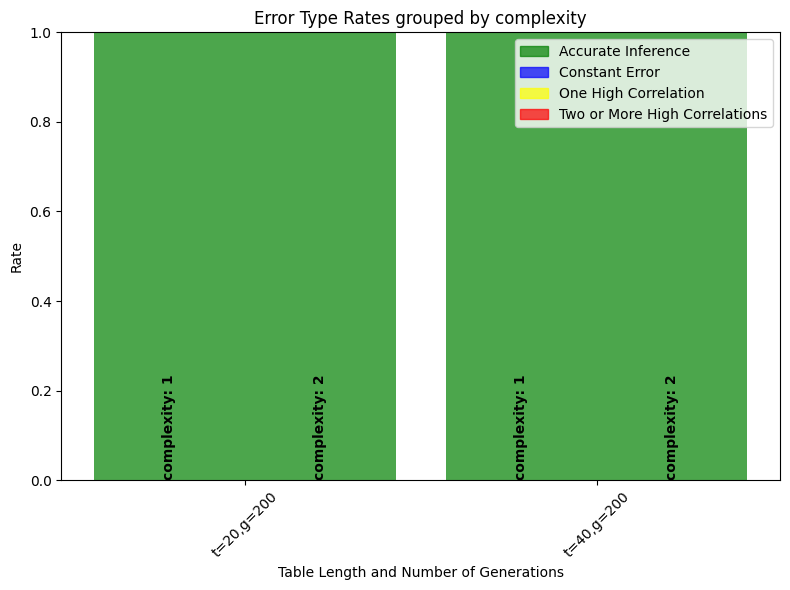

In [23]:
# Stacked bar chart: grouped by (tableLength,numGenerations), bars grouped per complexity
errorTypes = ['Accurate Inference', 'Constant Error', 'One High Correlation', 'Two or More High Correlations']
colors = ['green', 'blue', 'yellow', 'red']
# get unique (tableLength,numGenerations) combinations in sorted order
group_keys = errorAnalysis[['tableLength','numGenerations']].drop_duplicates().sort_values(['tableLength','numGenerations'])
labels = [f"t={int(r['tableLength'])},g={int(r['numGenerations'])}" for _, r in group_keys.iterrows()]
n_groups = len(labels)
n_complexities = len(complexities)
bar_width = 0.15
group_spacing = 0.05
group_width = n_complexities * bar_width + group_spacing
x_groups = np.arange(n_groups) * group_width
plt.figure(figsize=(max(8, n_groups*1.2), 6))
# collect the final stacked heights per complexity
for ci, comp in enumerate(complexities):
    bottoms = np.zeros(n_groups)
    comp_subset = errorAnalysis[errorAnalysis['complexity'] == comp].set_index(['tableLength','numGenerations'])
    positions = x_groups + (ci - (n_complexities - 1) / 2.0) * bar_width
    for ei, et in enumerate(errorTypes):
        vals = []
        for _, r in group_keys.iterrows():
            key = (r['tableLength'], r['numGenerations'])
            if key in comp_subset.index:
                v = comp_subset.loc[key, et]
                try:
                    vals.append(float(v))
                except Exception:
                    vals.append(0.0)
            else:
                vals.append(0.0)
        plt.bar(positions, vals, bar_width, bottom=bottoms, color=colors[ei], label=et if ci == 0 else "", alpha=0.7)
        bottoms += np.array(vals)
    # annotate each bar (grouped position for this complexity) with complexity label above the stacked bar
    # compute reasonable offset based on data range
    max_height = np.max(bottoms) if len(bottoms) > 0 else 0.0
    for pos, total in zip(positions, bottoms):
        plt.text(pos, 0, f'complexity: {comp}', ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
# set x ticks to group centers
plt.xticks(x_groups, labels, rotation=45)
plt.xlabel('Table Length and Number of Generations')
plt.ylabel('Rate')
plt.title('Error Type Rates grouped by complexity')
# legend showing error correlation types
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in colors]
plt.legend(handles, errorTypes)
plt.tight_layout()
plt.show()


/Users/petreanorgren/anaconda3/envs/TER_legacy/lib/python3.10/site-packages/pandas/core/indexes/base.py:6982: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  return Index(sequences[0], name=names)


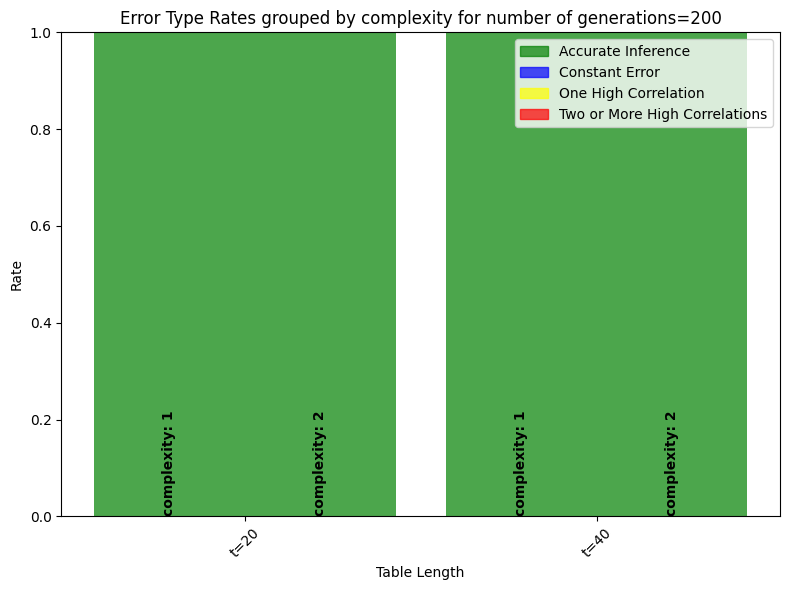

In [24]:
# One stacked bar chart for each numGenerations: grouped by tableLength, bars grouped per complexity
errorTypes = ['Accurate Inference', 'Constant Error', 'One High Correlation', 'Two or More High Correlations']
colors = ['green', 'blue', 'yellow', 'red']

for g in numGenerations:
    subset_g = errorAnalysis[errorAnalysis['numGenerations'] == g]
    group_keys = subset_g[['tableLength']].drop_duplicates().sort_values(['tableLength'])
    labels = [f"t={int(r['tableLength'])}" for _, r in group_keys.iterrows()]
    n_groups = len(labels)
    n_complexities = len(complexities)
    bar_width = 0.15
    group_spacing = 0.05
    group_width = n_complexities * bar_width + group_spacing
    x_groups = np.arange(n_groups) * group_width
    plt.figure(figsize=(max(8, n_groups*1.2), 6))
    for ci, comp in enumerate(complexities):
        bottoms = np.zeros(n_groups)
        comp_subset = subset_g[subset_g['complexity'] == comp].set_index(['tableLength'])
        positions = x_groups + (ci - (n_complexities - 1) / 2.0) * bar_width
        for ei, et in enumerate(errorTypes):
            vals = []
            for _, r in group_keys.iterrows():
                key = (r['tableLength'])
                if key in comp_subset.index:
                    v = comp_subset.loc[key, et]
                    try:
                        vals.append(float(v))
                    except Exception:
                        vals.append(0.0)
                else:
                    vals.append(0.0)
            plt.bar(positions, vals, bar_width, bottom=bottoms, color=colors[ei], label=et if ci == 0 else "", alpha=0.7)
            bottoms += np.array(vals)
        max_height = np.max(bottoms) if len(bottoms) > 0 else 0.0
        for pos, total in zip(positions, bottoms):
            plt.text(pos, 0, f'complexity: {comp}', ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
    plt.xticks(x_groups, labels, rotation=45)
    plt.xlabel('Table Length')
    plt.ylabel('Rate')
    plt.title(f'Error Type Rates grouped by complexity for number of generations={g}')
    handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in colors]
    plt.legend(handles, errorTypes)
    plt.tight_layout()
    plt.show()


In [25]:
numInputParameters = 2
parameterRange = (0, 100)

seed = 42
testdf = create_input_samples(numInputParameters=numInputParameters, parameterRange=parameterRange, tableLength=100, random_seed=seed)
print(testdf.columns)

Index(['i0', 'i1', 'r0', 'r1'], dtype='object')


In [26]:
trueFunction = 'add(mul(i0, 2), i1)'
testdf = get_true_function_output(trueFunction, testdf)
fakeFunctions = {}
offByConst = f'add({trueFunction}, 5)'
fakeFunctions['off by constant term'] = offByConst #off by a constant
offByScaleInOneVar = trueFunction.replace('2', '3')
fakeFunctions['off by scale in one variable'] = offByScaleInOneVar #off by a scale in one variable
fakeFunctions['off by scale in one variable and a constant term'] = f'add({offByScaleInOneVar}, 1)' #off by a scale in one variable plus a constant
addWrongVarFunc = 'add(' + trueFunction + ', r1)'
fakeFunctions['off by adding extra variable'] = addWrongVarFunc #off by adding a wrong variable 
fakeFunctions['off by adding extra variable plus constant'] = f'add({addWrongVarFunc}, 2)' #off by adding a wrong variable instead of a constant plus a constant
wrongVarFunc = trueFunction.replace('i0', 'r2')
fakeFunctions['off by using wrong variable'] = wrongVarFunc #off by using a wrong variable instead of one in the true function
fakeFunctions['off by using wrong variable plus constant'] = f'add({wrongVarFunc}, 1)' #off by using a wrong variable instead of one in the true function plus a constant
fakeFunctions['Completly wrong function'] = 'add(mul(r0, r1), r2)' #completely wrong function

print('Fake functions being tested: ')
for func in fakeFunctions:
    print(f" - {func}: {fakeFunctions[func]}")

trueOut = testdf['o'].values
testOuts = {}
pset = setup_pset(testdf)
for func in fakeFunctions.values():
    treeInferred = gp.PrimitiveTree.from_string(func, pset)
    funcCompiled = gp.compile(treeInferred, pset)
    output = testdf.drop(columns=['o']).apply(lambda row: funcCompiled(**row.to_dict()), axis=1).values
    testOuts[func] = output

Fake functions being tested: 
 - off by constant term: add(add(mul(i0, 2), i1), 5)
 - off by scale in one variable: add(mul(i0, 3), i1)
 - off by scale in one variable and a constant term: add(add(mul(i0, 3), i1), 1)
 - off by adding extra variable: add(add(mul(i0, 2), i1), r1)
 - off by adding extra variable plus constant: add(add(add(mul(i0, 2), i1), r1), 2)
 - off by using wrong variable: add(mul(r2, 2), i1)
 - off by using wrong variable plus constant: add(add(mul(r2, 2), i1), 1)
 - Completly wrong function: add(mul(r0, r1), r2)


In [136]:

trueFunction = setFunction([d for d in testdf.columns], complexity=3)
print(f"True function: {trueFunction}")
trueFunction = 'add(mul(i3, 2), r1)'
testdf = get_true_function_output(trueFunction, testdf)
print(testdf.head())
fakeFunctions = {}
offByConst = f'add({trueFunction}, 5)'
fakeFunctions['off by constant term'] = offByConst #off by a constant
possibleVars = [v for v in testdf.columns if v != 'o']


#realised the statements are not true here as the nestled structure of the functions can make more things wrong than stated,
# but can be used as a way to generate functions with different types of errors to test the error analysis and correlation analysis functions on

for var in possibleVars:
    if var in trueFunction:
        offByScaleInOneVar = trueFunction.replace(var, f'mul(2, {var})')
        fakeFunctions['off by scale in one variable'] = offByScaleInOneVar #off by a scale in one variable
        offByScaleInOneVarPlusConst = f'add({offByScaleInOneVar}, 1)'
        fakeFunctions['off by scale in one variable and a constant term'] = offByScaleInOneVarPlusConst #off by a scale in one variable plus a constant
        for v in possibleVars:
            if v not in trueFunction and v != var:
                addWrongVarFunc = 'add(' + trueFunction + ',' + v + ')'
                fakeFunctions['off by adding extra variable'] = addWrongVarFunc #off by adding a wrong variable instead of a constant
                fakeFunctions['off by adding extra variable plus constant'] = f'add({addWrongVarFunc}, 2)' #off by adding a wrong variable instead of a constant plus a constant
                wrongVarFunc = trueFunction.replace(var, v)
                fakeFunctions['off by using wrong variable'] = wrongVarFunc #off by using a wrong variable instead of one in the true function
                fakeFunctions['off by using wrong variable plus constant'] = f'add({wrongVarFunc}, 1)' #off by using a wrong variable instead of one in the true function plus a constant
        break # only do for the first variable found in the true function

print('Fake functions being tested: ')
for func in fakeFunctions:
    print(f" - {func}: {fakeFunctions[func]}")

trueOut = testdf['o'].values
testOuts = {}
pset = setup_pset(testdf)
for func in fakeFunctions.values():
    treeInferred = gp.PrimitiveTree.from_string(func, pset)
    funcCompiled = gp.compile(treeInferred, pset)
    output = testdf.drop(columns=['o']).apply(lambda row: funcCompiled(**row.to_dict()), axis=1).values
    testOuts[func] = output


True function: add(r0,sub(r3,add(i0,r2)))


TypeError: Unable to evaluate terminal: i3.

In [32]:
testdf.head(5)


,i0,i1,i2,r0,r1,r2,r3,o
0,51,88,36,25,61,19,0,190
1,92,59,96,51,88,36,190,243
2,14,40,50,92,59,96,243,68
3,71,28,43,14,40,50,68,170
4,60,14,23,71,28,43,170,134


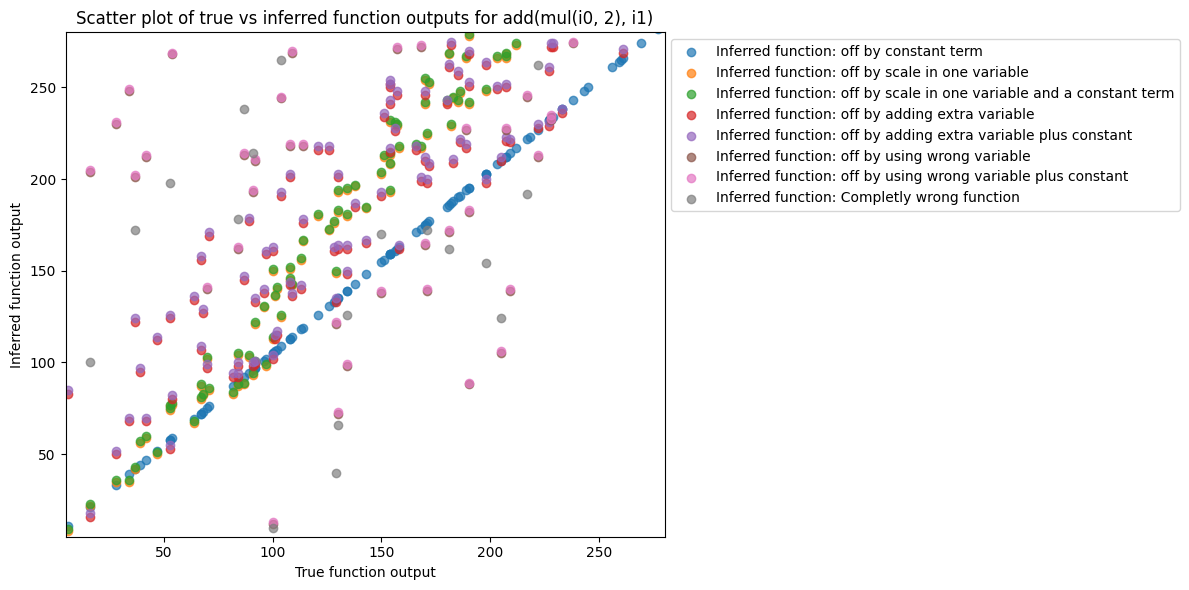

In [139]:
plt.figure(figsize=(12, 6))
for func in fakeFunctions.keys():
    plt.scatter(trueOut, testOuts[fakeFunctions[func]], label=f'Inferred function: {func}', alpha=0.7)
plt.xlabel('True function output')
plt.ylabel('Inferred function output')
plt.xlim(trueOut.min() - 1, trueOut.max() + 1)
plt.ylim(trueOut.min() - 1, trueOut.max() + 1)
plt.title(f'Scatter plot of true vs inferred function outputs for {trueFunction}')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

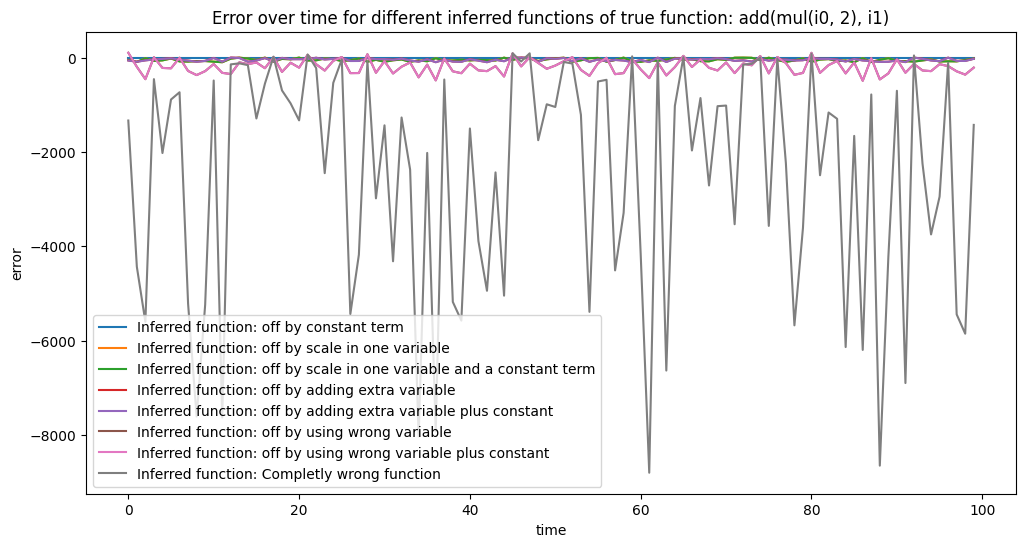

In [140]:
#residual error for each fake function over time
plt.figure(figsize=(12, 6))
for func in fakeFunctions.keys():
    error = trueOut - testOuts[fakeFunctions[func]]
    plt.plot(np.arange(100), error, label=f'Inferred function: {func}')
plt.title(f'Error over time for different inferred functions of true function: {trueFunction}')
plt.xlabel('time')
plt.ylabel('error')
plt.legend()



Inferred function off by constant term has constant error, skipping correlation analysis.


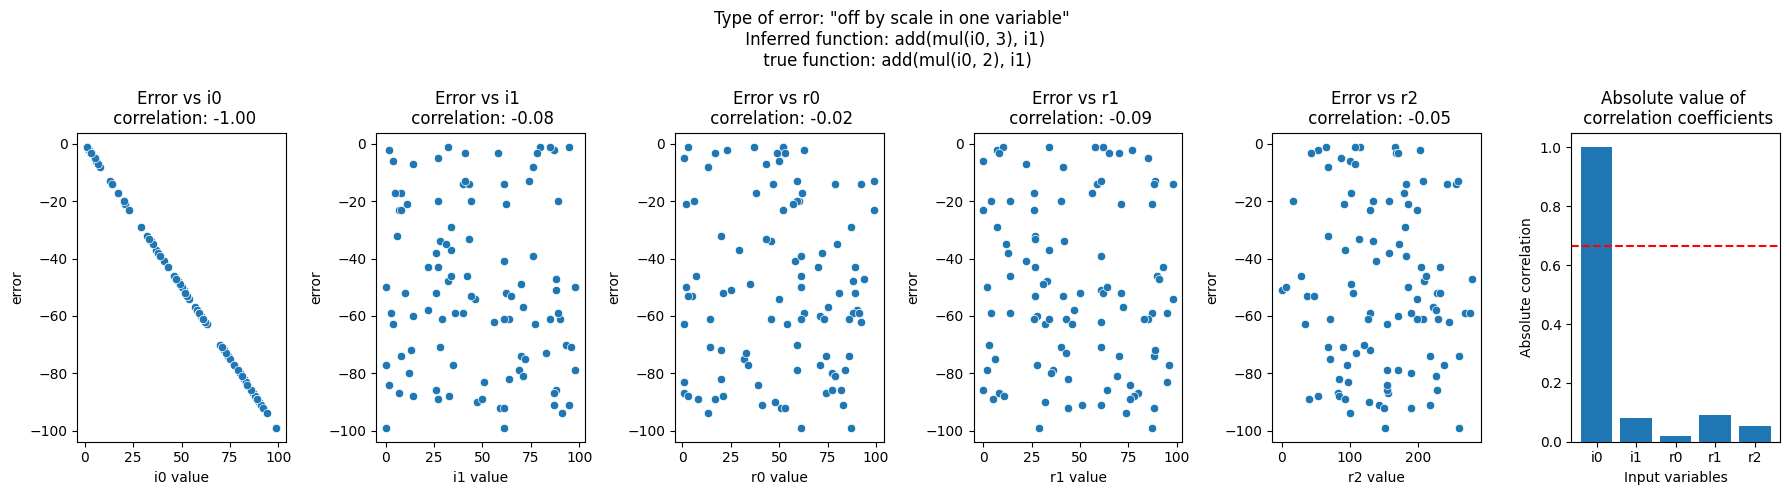

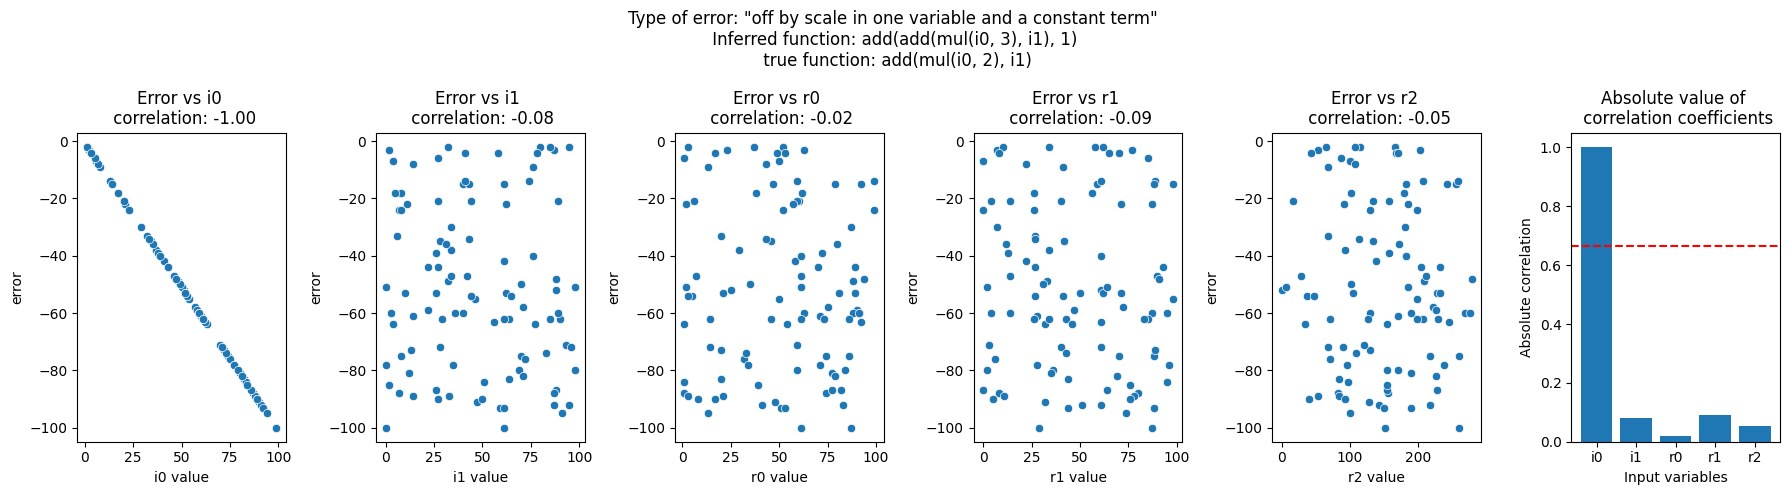

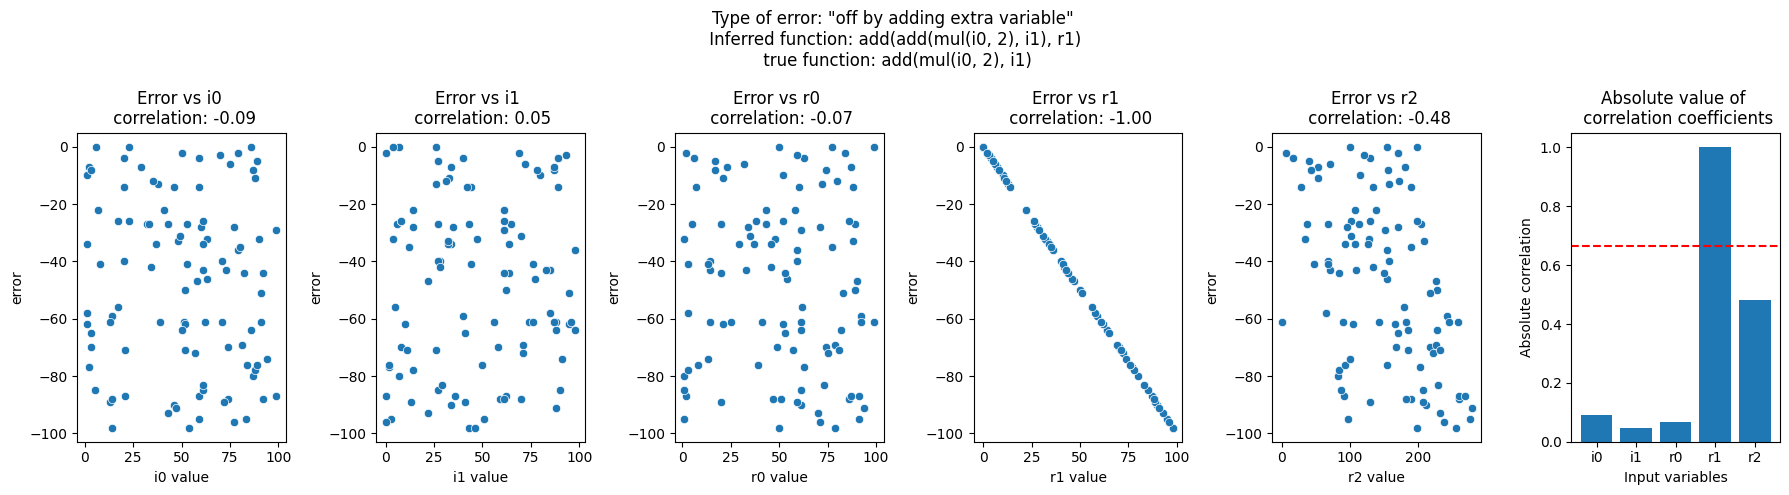

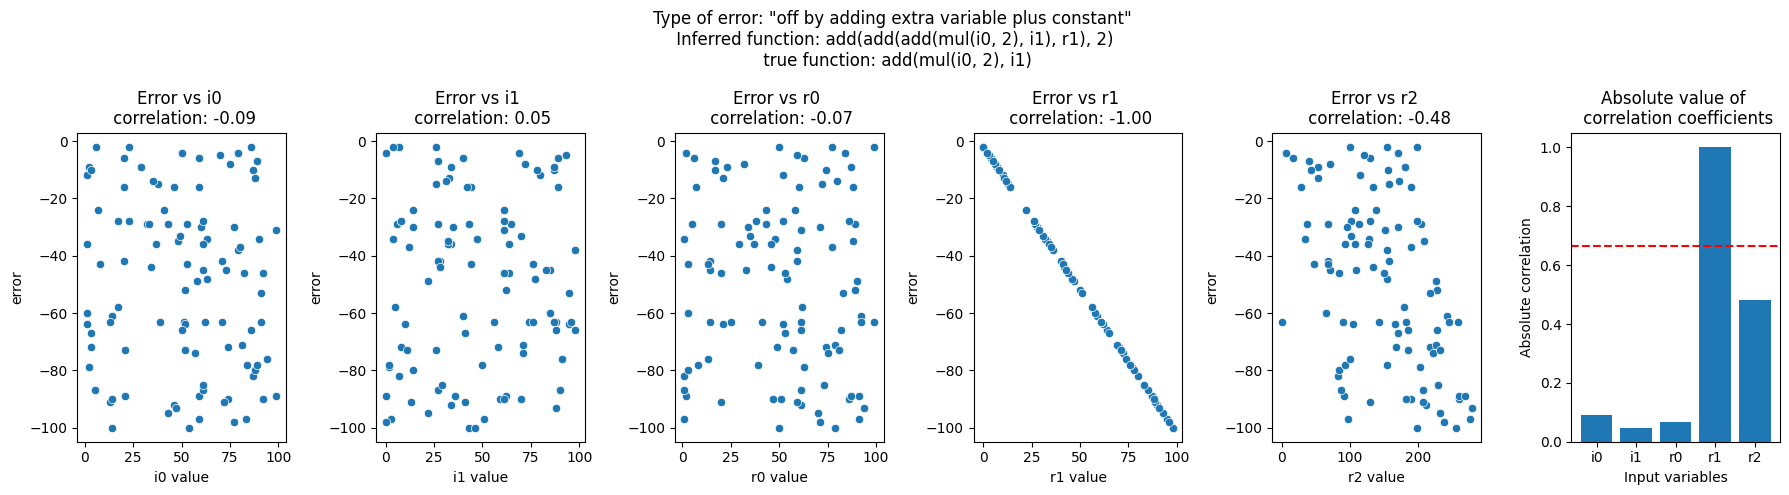

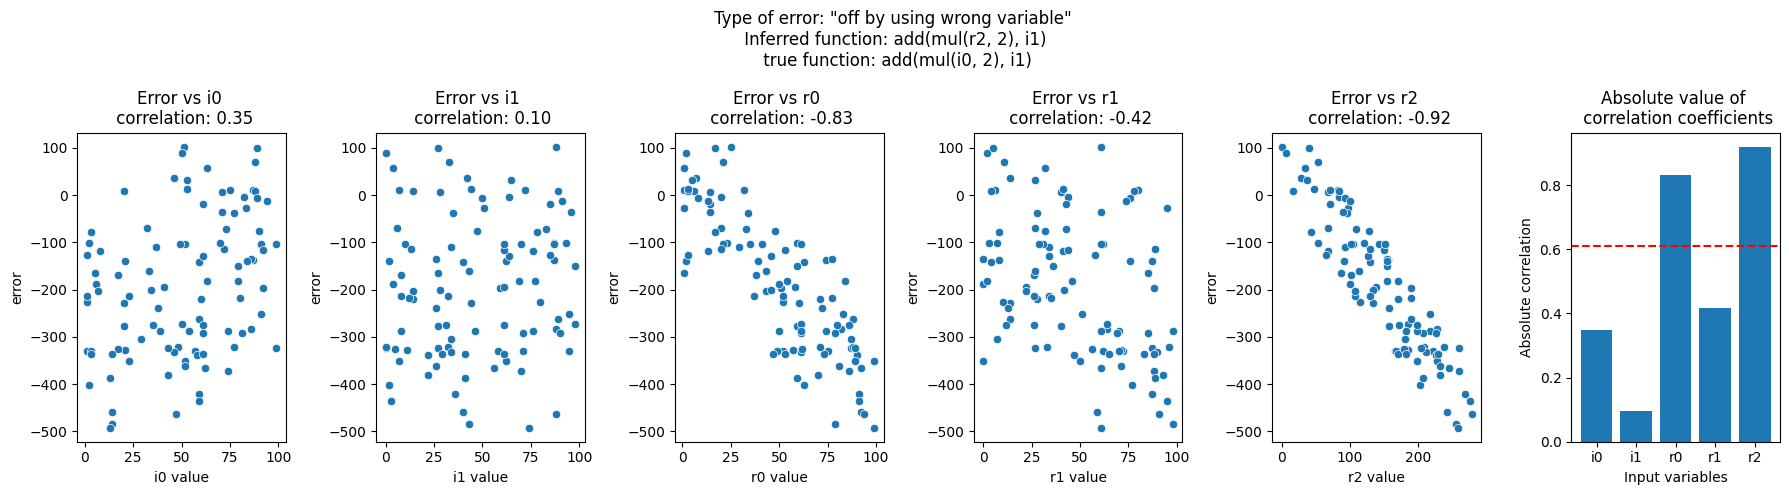

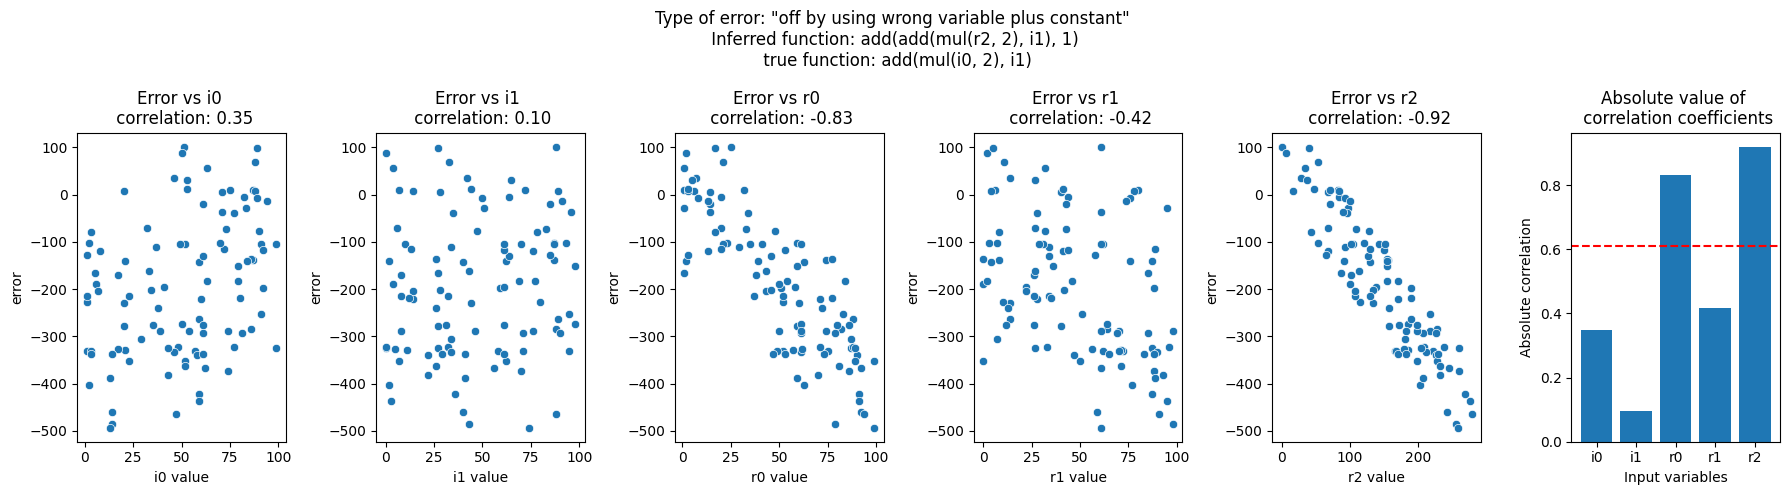

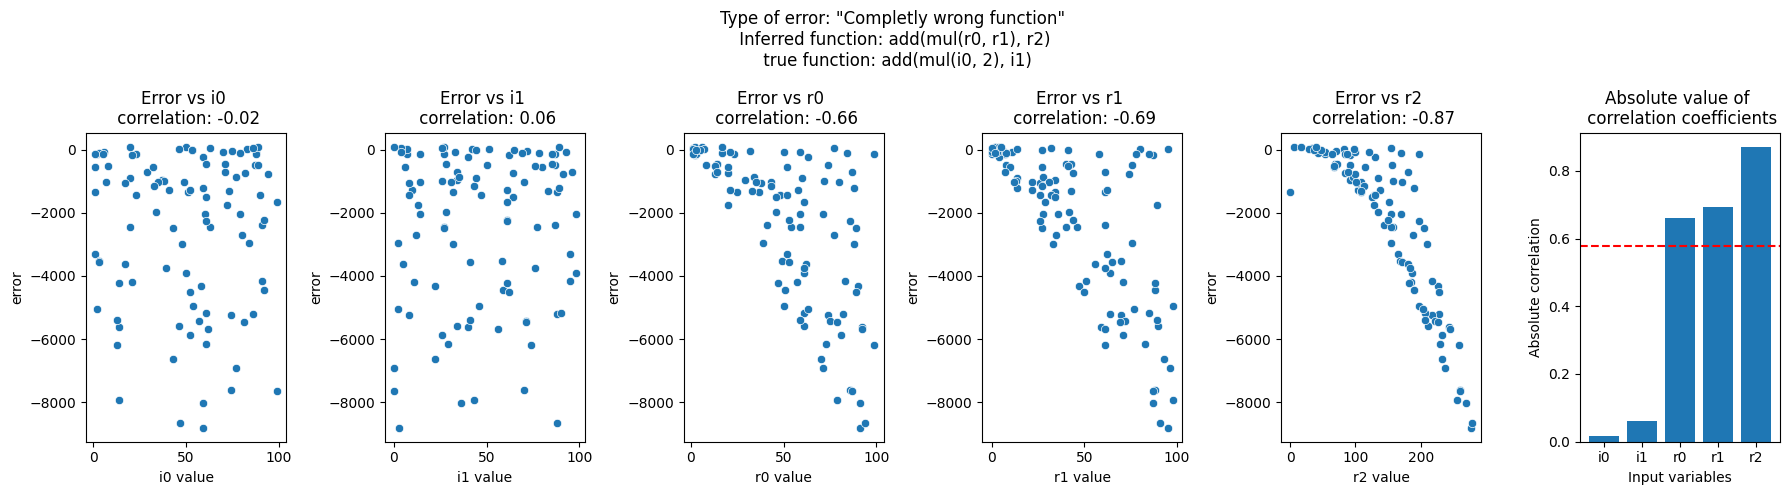

In [141]:
import seaborn as sns
import scipy.stats as stats
from scipy.signal import correlate

correlationCoefficients = []
#test of correlation of error with inputs
for func in fakeFunctions.keys():
    correlationCoefficients = []
    error =  trueOut - testOuts[fakeFunctions[func]]
    if np.all(error == error[0]):
        print(f'Inferred function {func} has constant error, skipping correlation analysis.')
    else:
        fig, axes = plt.subplots(1, len(testdf.columns), figsize=(3*len(testdf.columns), 5))
        if len(testdf.drop(columns=['o']).columns) == 1:
            axes = [axes]
        for i, col in enumerate(testdf.drop(columns=['o']).columns):
            sns.scatterplot(x=testdf[col].values, y=error, ax=axes[i])
            corr = np.corrcoef(testdf[col].values, error)[0,1]
            correlationCoefficients.append(abs(corr))
            axes[i].set_title(f'Error vs {col} \n correlation: {corr:.2f}')
            axes[i].set_xlabel(f'{col} value')
            axes[i].set_ylabel('error')
        
        halfmax = max(correlationCoefficients) * 2 / 3
        axes[-1].axhline(halfmax, color='red', linestyle='--', label=f'Half max correlation: {halfmax:.2f}')
        axes[-1].bar(testdf.drop(columns=['o']).columns, correlationCoefficients)
        axes[-1].set_title('Absolute value of \n correlation coefficients')
        axes[-1].set_xlabel('Input variables')
        axes[-1].set_ylabel('Absolute correlation')
        fig.suptitle(f'Type of error: "{func}" \n Inferred function: {fakeFunctions[func]} \n true function: {trueFunction}')
        plt.tight_layout()
        plt.show()


Inferred function off by constant term has constant error, skipping correlation analysis.
1-step autocorrelation of error with i0: -0.018486738028077952
R2 of linear regression of 1-step lagged error on i0: 0.0003417594829189241
1-step autocorrelation of error with i1: -0.0918110144684303
R2 of linear regression of 1-step lagged error on i1: 0.008429262377722568


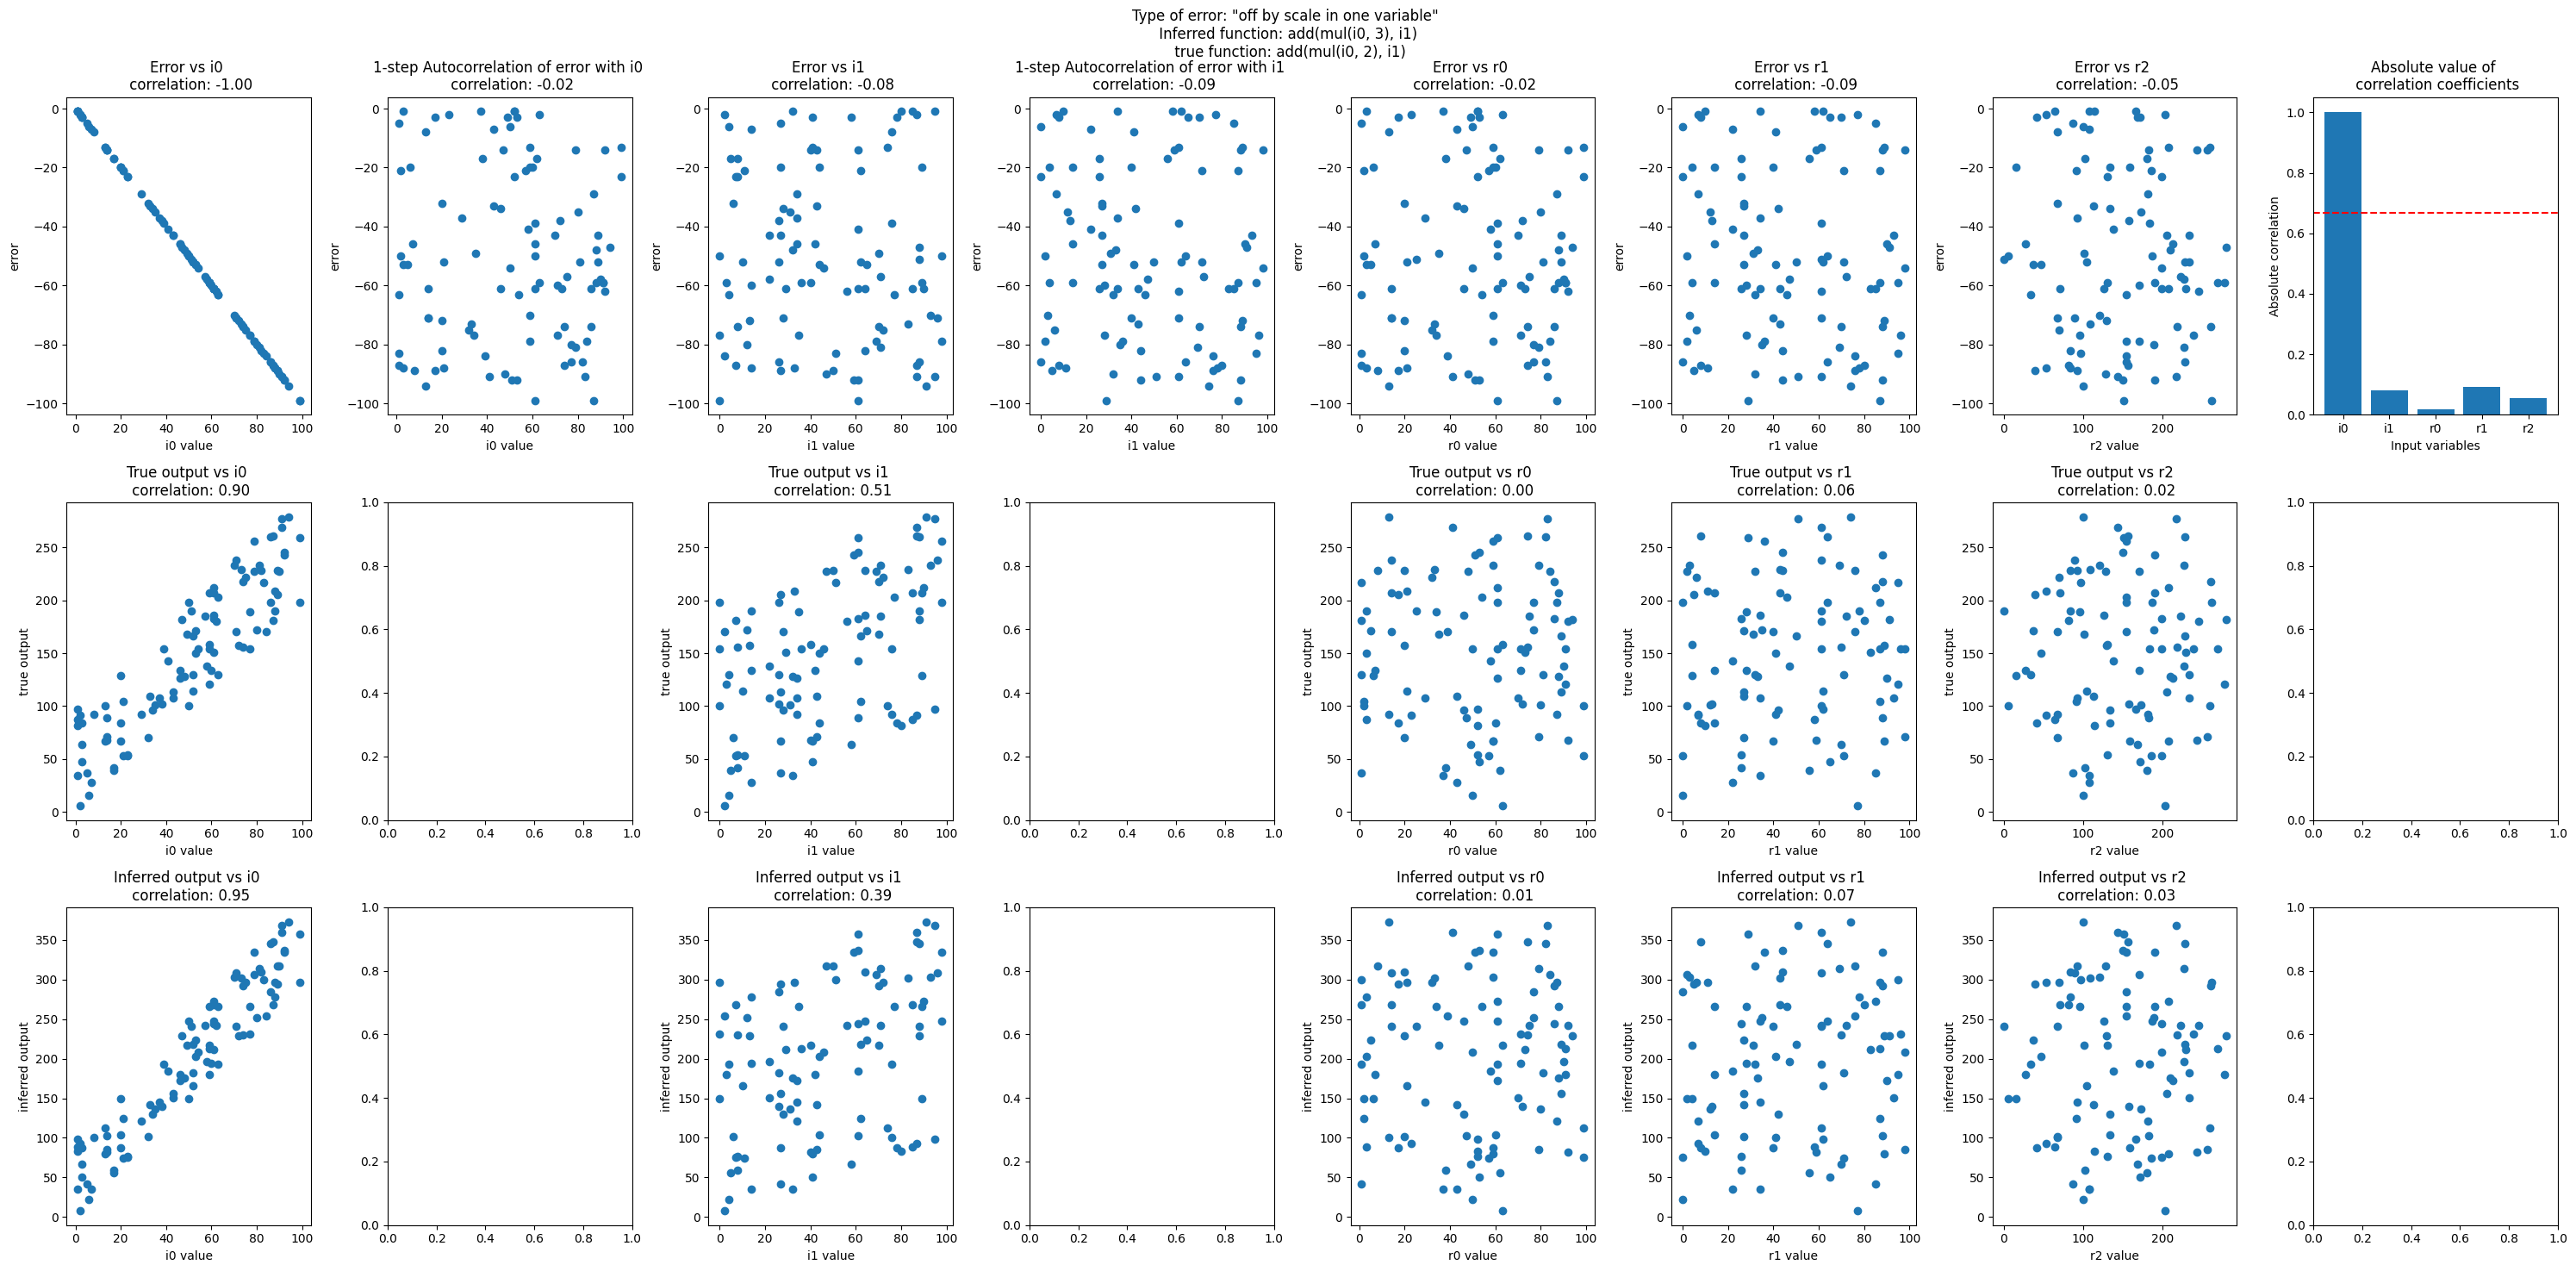

1-step autocorrelation of error with i0: -0.018486738028077952
R2 of linear regression of 1-step lagged error on i0: 0.0003417594829189241
1-step autocorrelation of error with i1: -0.0918110144684303
R2 of linear regression of 1-step lagged error on i1: 0.008429262377722568


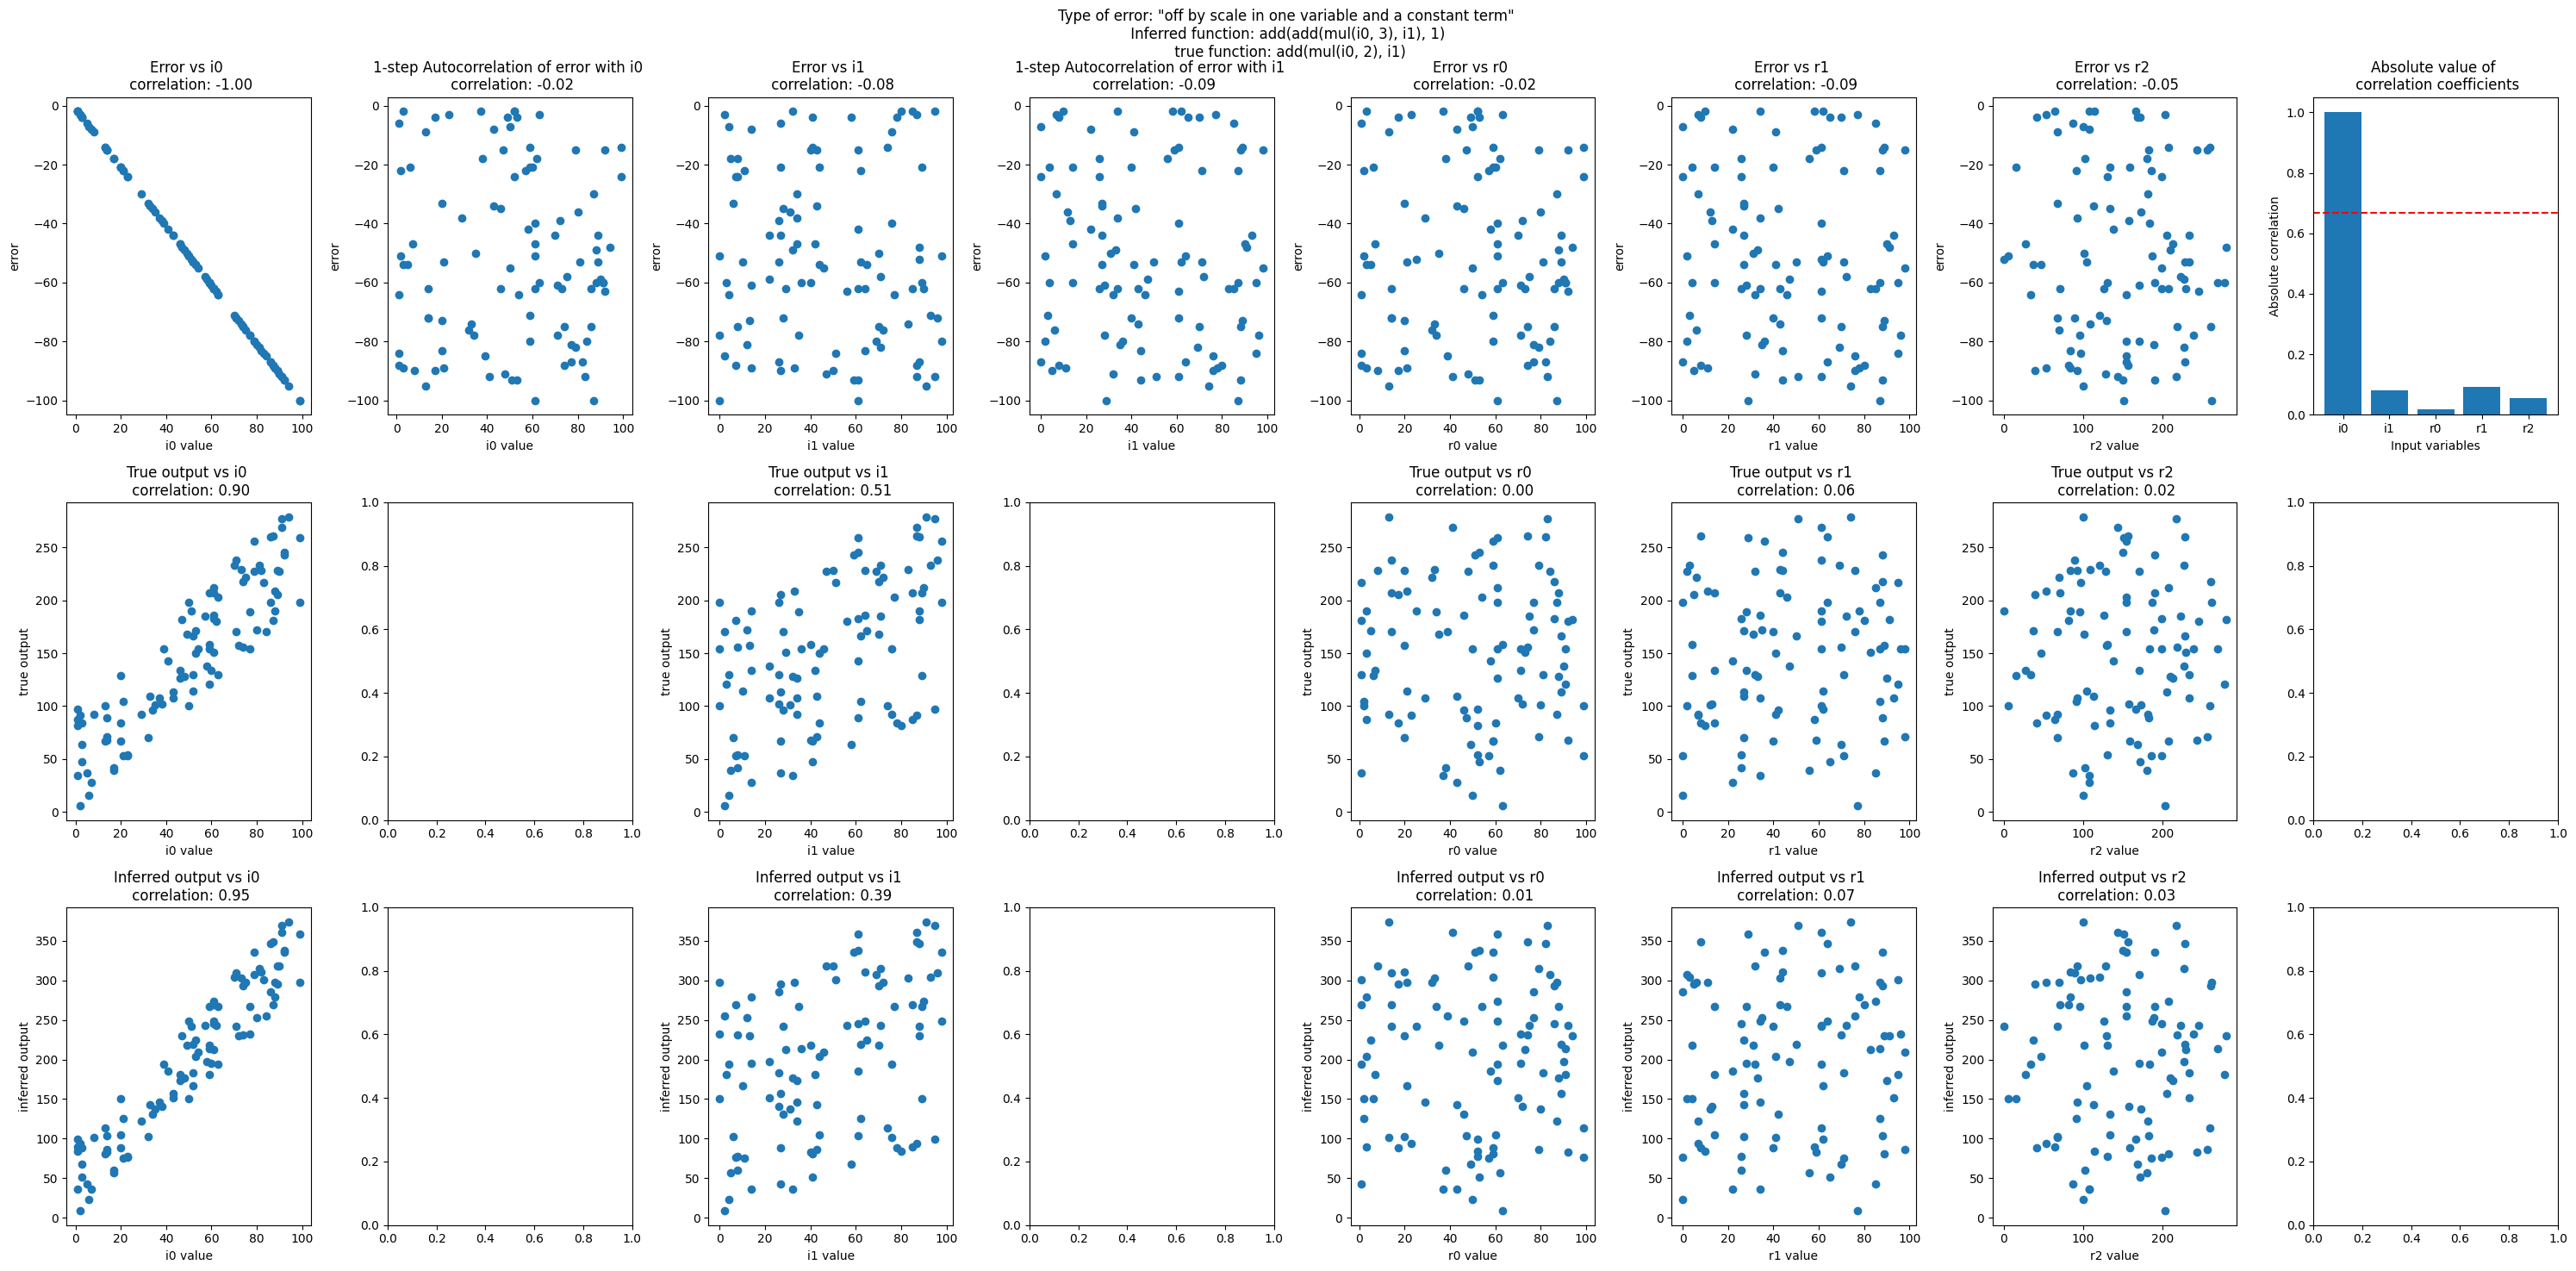

1-step autocorrelation of error with i0: -0.07056186832223062
R2 of linear regression of 1-step lagged error on i0: 0.00497897726112384
1-step autocorrelation of error with i1: -0.9999999999999999
R2 of linear regression of 1-step lagged error on i1: 1.0


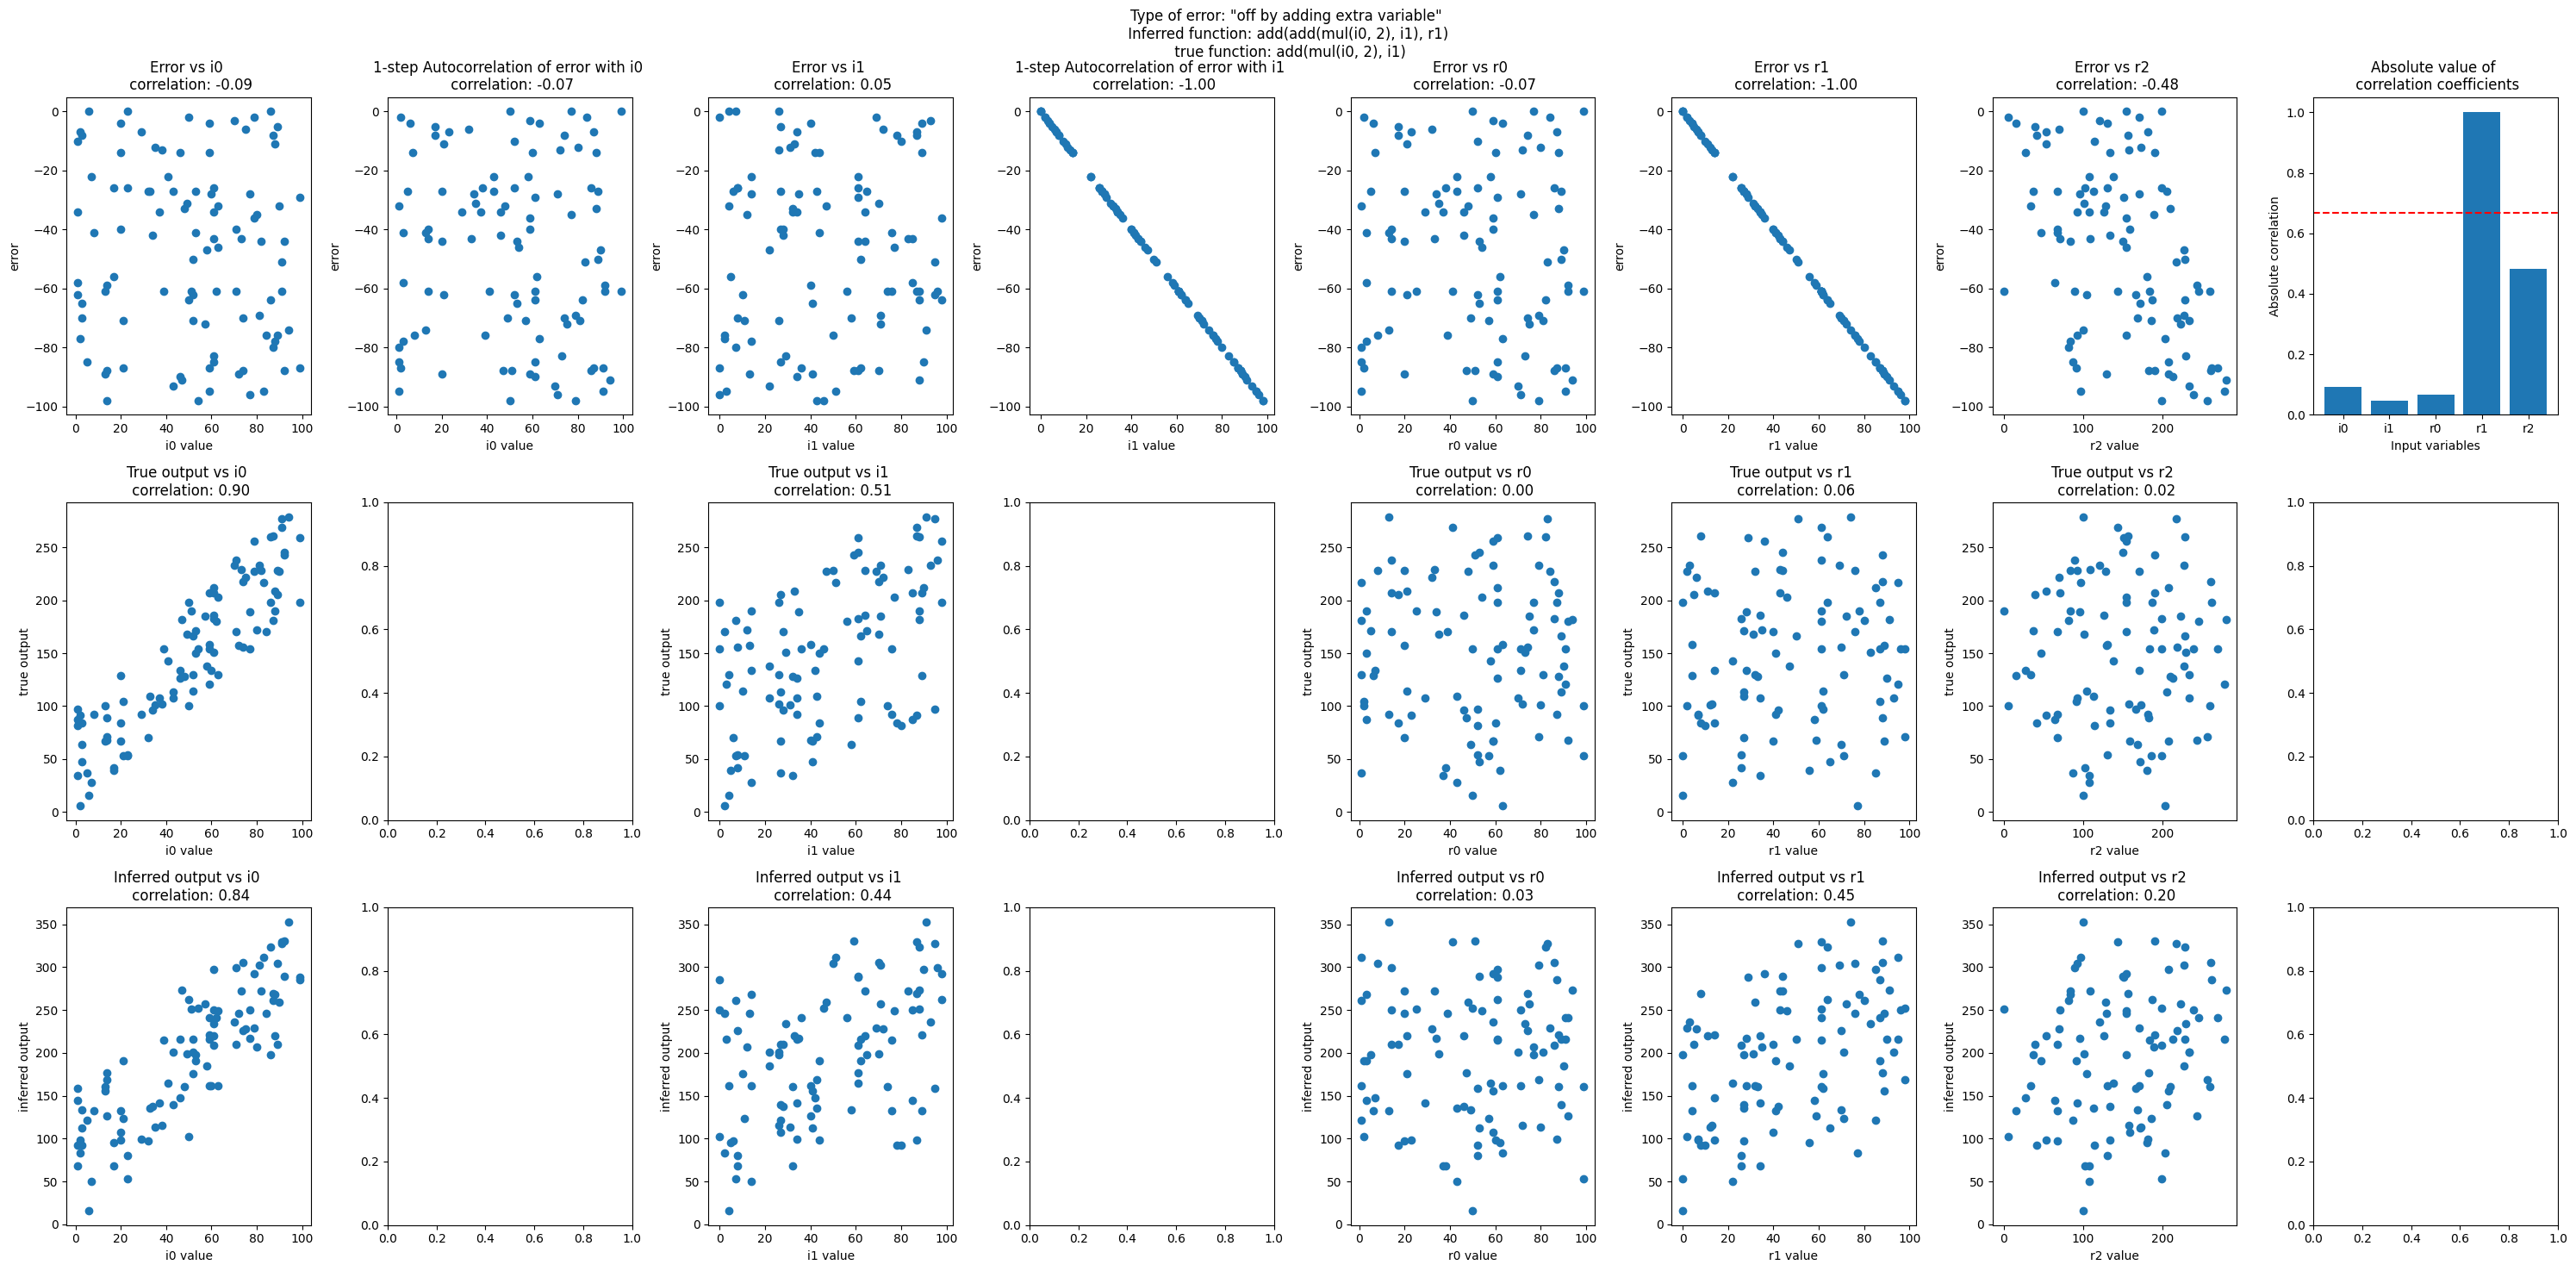

1-step autocorrelation of error with i0: -0.07056186832223062
R2 of linear regression of 1-step lagged error on i0: 0.00497897726112384
1-step autocorrelation of error with i1: -0.9999999999999999
R2 of linear regression of 1-step lagged error on i1: 1.0


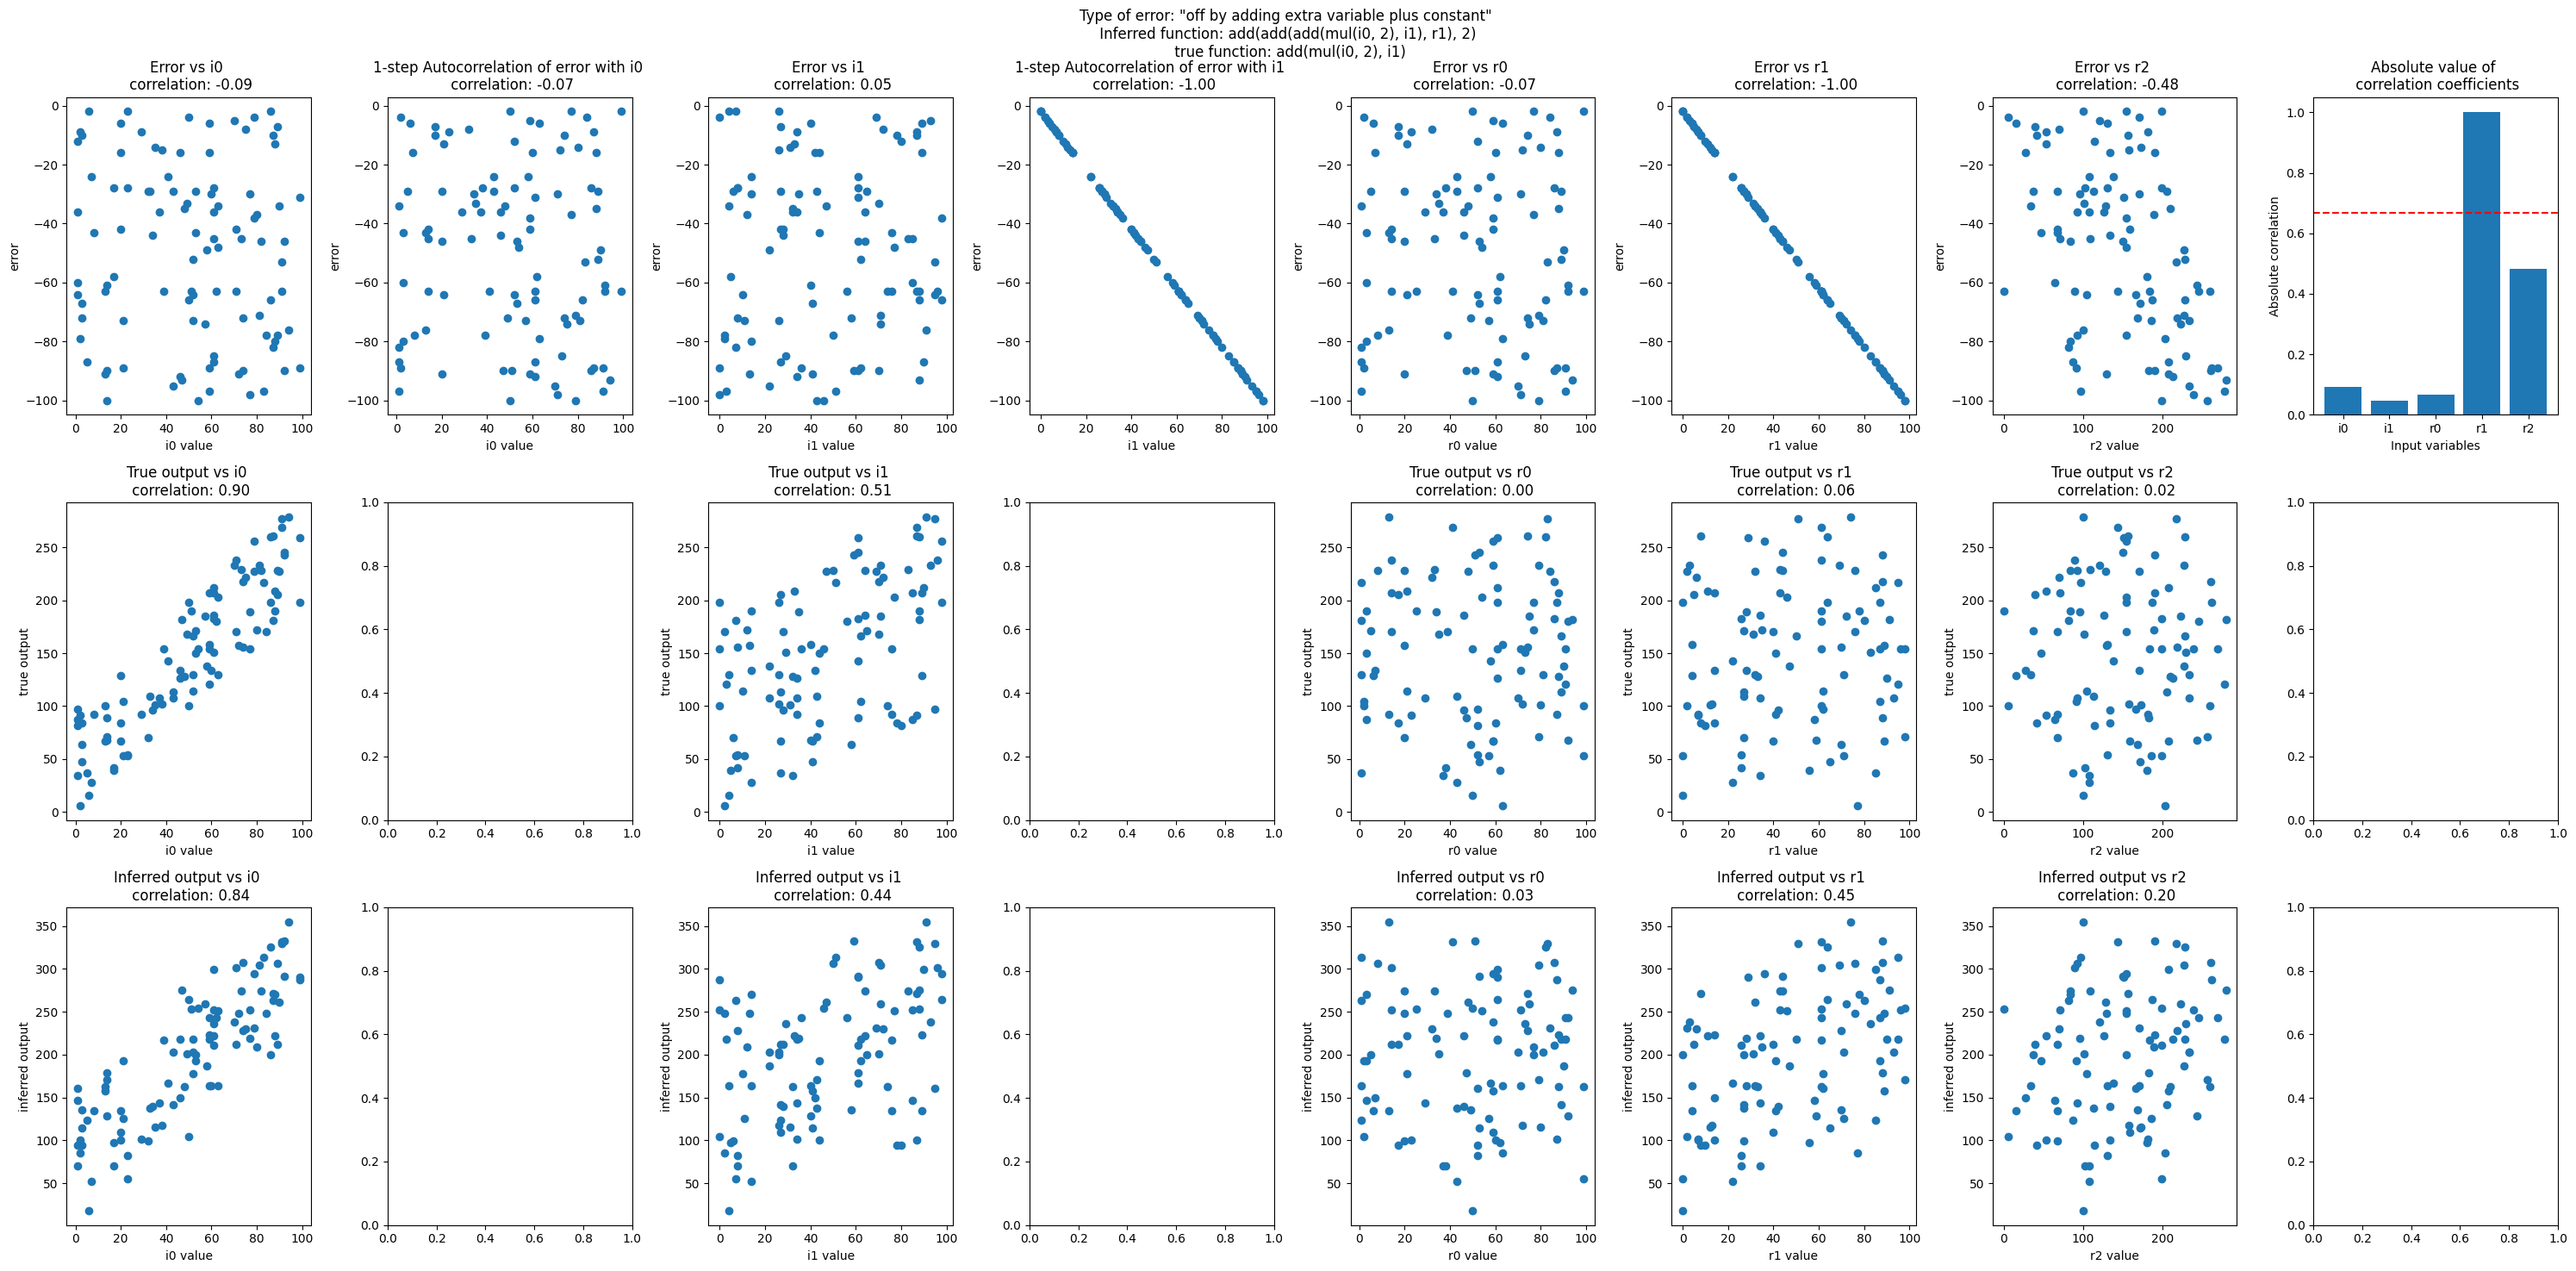

1-step autocorrelation of error with i0: -0.83307318805576
R2 of linear regression of 1-step lagged error on i0: 0.6940109366573874
1-step autocorrelation of error with i1: -0.4337952645607176
R2 of linear regression of 1-step lagged error on i1: 0.18817833155530306


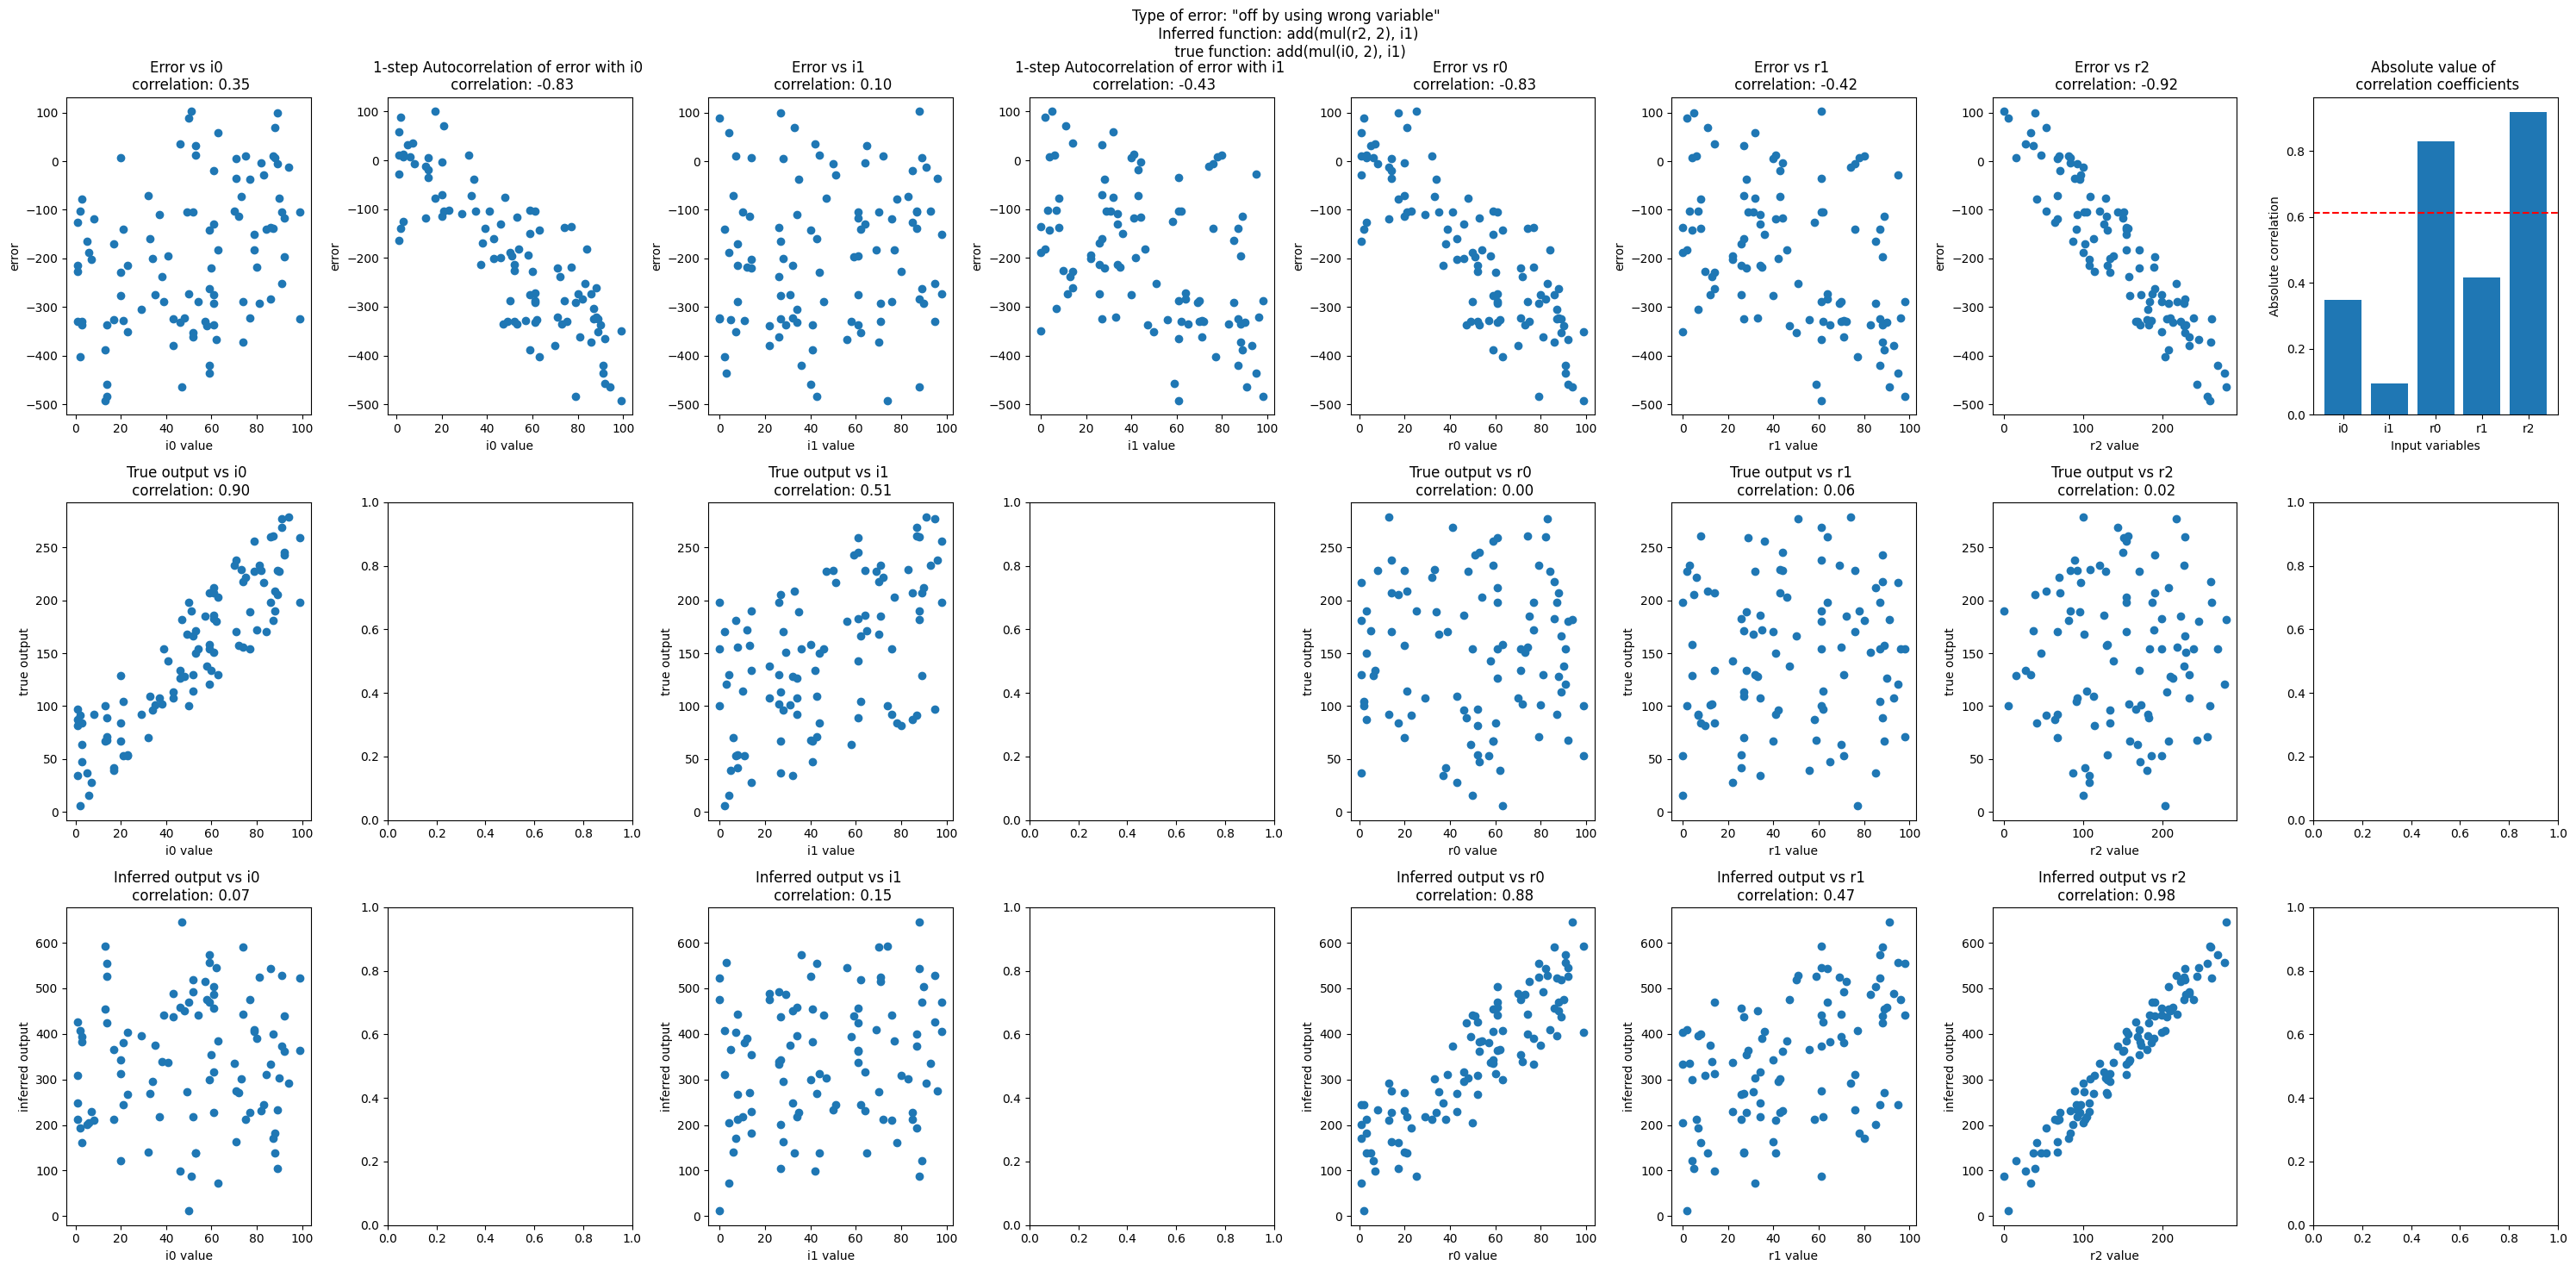

1-step autocorrelation of error with i0: -0.83307318805576
R2 of linear regression of 1-step lagged error on i0: 0.6940109366573874
1-step autocorrelation of error with i1: -0.4337952645607176
R2 of linear regression of 1-step lagged error on i1: 0.18817833155530306


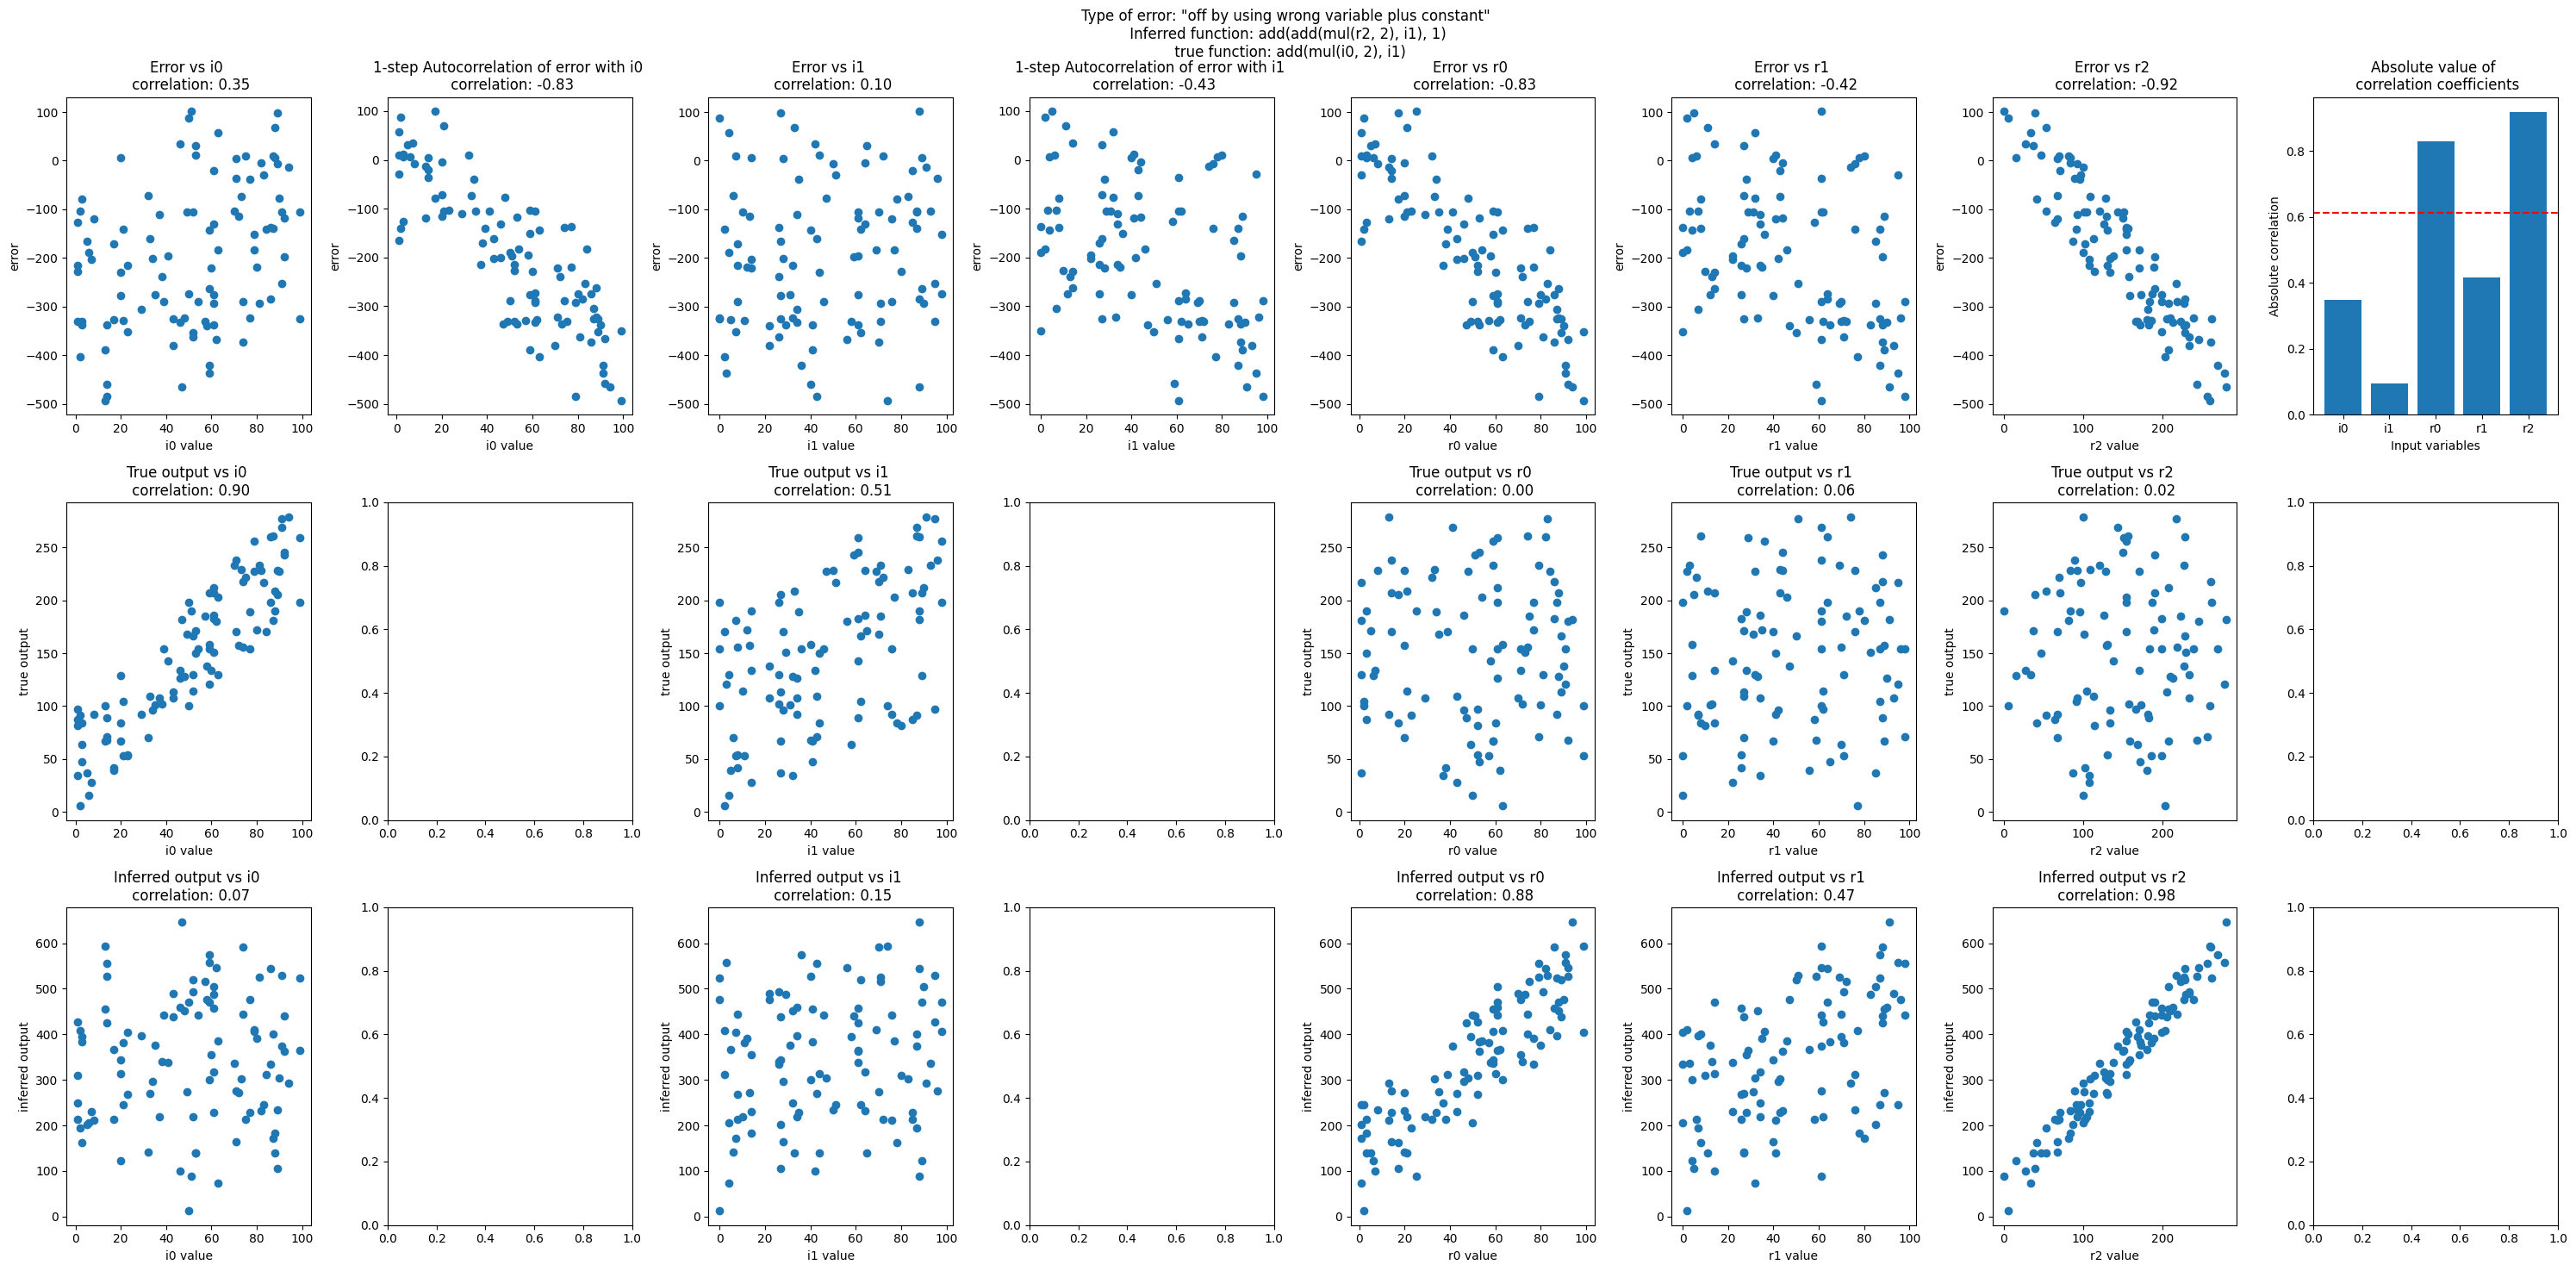

1-step autocorrelation of error with i0: -0.6606974689481891
R2 of linear regression of 1-step lagged error on i0: 0.43652114547454335
1-step autocorrelation of error with i1: -0.6969127547009405
R2 of linear regression of 1-step lagged error on i1: 0.48568738766485353


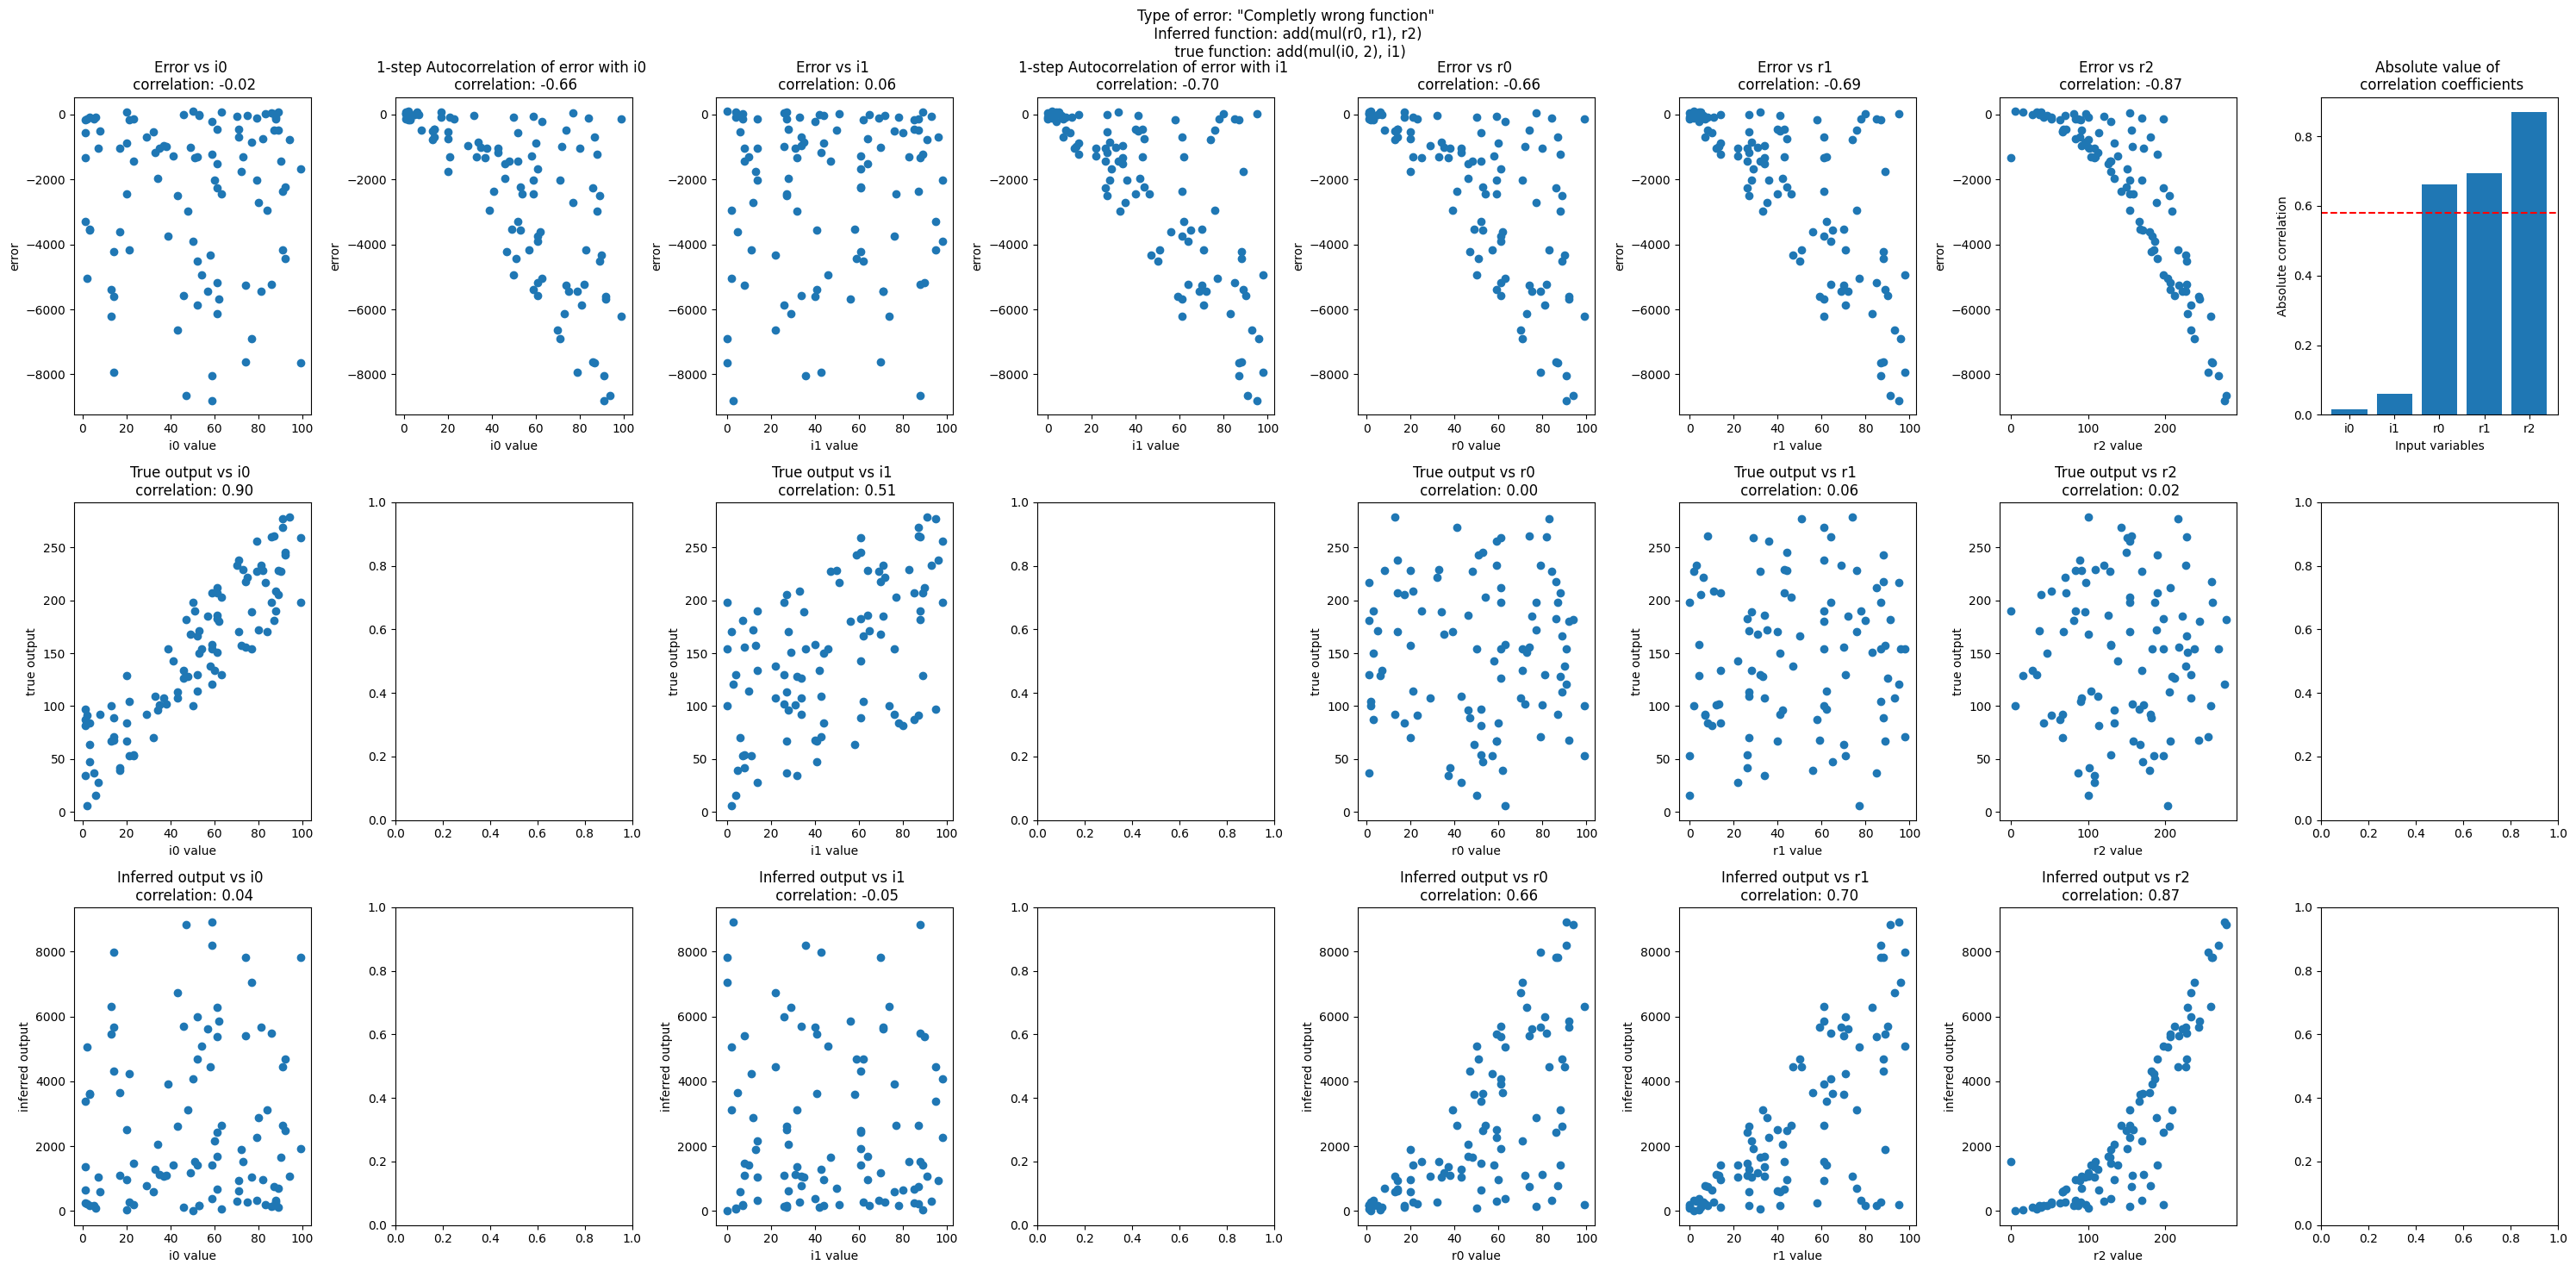

In [142]:
import seaborn as sns
import scipy.stats as stats
from scipy.signal import correlate
from sklearn.linear_model import LinearRegression

def check_autocorrelation(res, col):
    res = res - np.mean(res)
    res = res / np.std(res)
    col = col - np.mean(col)
    col = col / np.std(col)
    corr = correlate(res, col, mode='full')/len(res)
    print(f'Autocorrelation of error: {corr}')
    return corr

def r_squared(residuals, X_col):
    X = X_col.reshape(-1, 1)
    model = LinearRegression().fit(X, residuals)
    return model.score(X, residuals)
    

correlationCoefficients = []
#test of correlation of error with inputs
for func in fakeFunctions.keys():
    correlationCoefficients = []
    error =  trueOut - testOuts[fakeFunctions[func]]
    if np.all(error == error[0]):
        print(f'Inferred function {func} has constant error, skipping correlation analysis.')
    else:
        plots = len(testdf.columns) + len(testdf.drop(columns=['o']).columns) // 2
        fig, axes = plt.subplots(3, plots, figsize=(5*len(testdf.columns), 15))
        if len(testdf.drop(columns=['o']).columns) == 1:
            axes = [axes]
        j = 0
        for i, col in enumerate(testdf.drop(columns=['o']).columns):
            if col.startswith('i'):
                axes[0,j].scatter(testdf[col].values, error)
                corr = np.corrcoef(testdf[col].values, error)[0,1]
                correlationCoefficients.append(abs(corr))
                axes[0,j].set_title(f'Error vs {col} \n correlation: {corr:.2f}')
                axes[0,j].set_xlabel(f'{col} value')
                axes[0,j].set_ylabel('error')
                # print(f'R2 of linear regression of error on {col}: {r_squared(error, testdf[col].values)}')

                corr = np.corrcoef(testdf[col].values, trueOut)[0,1]
                axes[1,j].scatter(testdf[col].values, trueOut)
                axes[1,j].set_title(f'True output vs {col} \n correlation: {corr:.2f}')
                axes[1,j].set_xlabel(f'{col} value')
                axes[1,j].set_ylabel('true output')

                axes[2,j].scatter(testdf[col].values, testOuts[fakeFunctions[func]])
                corr = np.corrcoef(testdf[col].values, testOuts[fakeFunctions[func]])[0,1]
                axes[2,j].set_title(f'Inferred output vs {col} \n correlation: {corr:.2f}')
                axes[2,j].set_xlabel(f'{col} value')
                axes[2,j].set_ylabel('inferred output')
                # check 1-step autocorrelation of error with this register variable
                j += 1
                lagRes = error[1:]
                lagCol = testdf[col].values[:-1]
                axes[0,j].scatter(lagCol, lagRes)
                lagError = np.corrcoef(lagCol, lagRes)[0,1]
                print(f'1-step autocorrelation of error with {col}: {lagError}')
                print(f'R2 of linear regression of 1-step lagged error on {col}: {r_squared(lagRes, lagCol)}')
                axes[0,j].set_title(f'1-step Autocorrelation of error with {col} \n correlation: {lagError:.2f}')
                axes[0,j].set_xlabel(f'{col} value')
                axes[0,j].set_ylabel('error')
                j+= 1
            else:
                axes[0,j].scatter(testdf[col].values, error)
                corr = np.corrcoef(testdf[col].values, error)[0,1]
                correlationCoefficients.append(abs(corr))
                # print(f'R2 of linear regression of error on {col}: {r_squared(error, testdf[col].values)}')
                axes[0,j].set_title(f'Error vs {col} \n correlation: {corr:.2f}')
                axes[0,j].set_xlabel(f'{col} value')
                axes[0,j].set_ylabel('error')
                corr = np.corrcoef(testdf[col].values, trueOut)[0,1]
                axes[1,j].scatter(testdf[col].values, trueOut)
                axes[1,j].set_title(f'True output vs {col} \n correlation: {corr:.2f}')
                axes[1,j].set_xlabel(f'{col} value')
                axes[1,j].set_ylabel('true output')
                axes[2,j].scatter(testdf[col].values, testOuts[fakeFunctions[func]])
                corr = np.corrcoef(testdf[col].values, testOuts[fakeFunctions[func]])[0,1]
                axes[2,j].set_title(f'Inferred output vs {col} \n correlation: {corr:.2f}')
                axes[2,j].set_xlabel(f'{col} value')
                axes[2,j].set_ylabel('inferred output')
                j += 1
        # print(j)
        halfmax = max(correlationCoefficients) * 2 / 3
        axes[0,-1].axhline(halfmax, color='red', linestyle='--', label=f'Half max correlation: {halfmax:.2f}')
        axes[0,-1].bar(testdf.drop(columns=['o']).columns, correlationCoefficients)
        axes[0,-1].set_title('Absolute value of \n correlation coefficients')
        axes[0,-1].set_xlabel('Input variables')
        axes[0,-1].set_ylabel('Absolute correlation')
        fig.suptitle(f'Type of error: "{func}" \n Inferred function: {fakeFunctions[func]} \n true function: {trueFunction}')
        plt.tight_layout()
        plt.show()


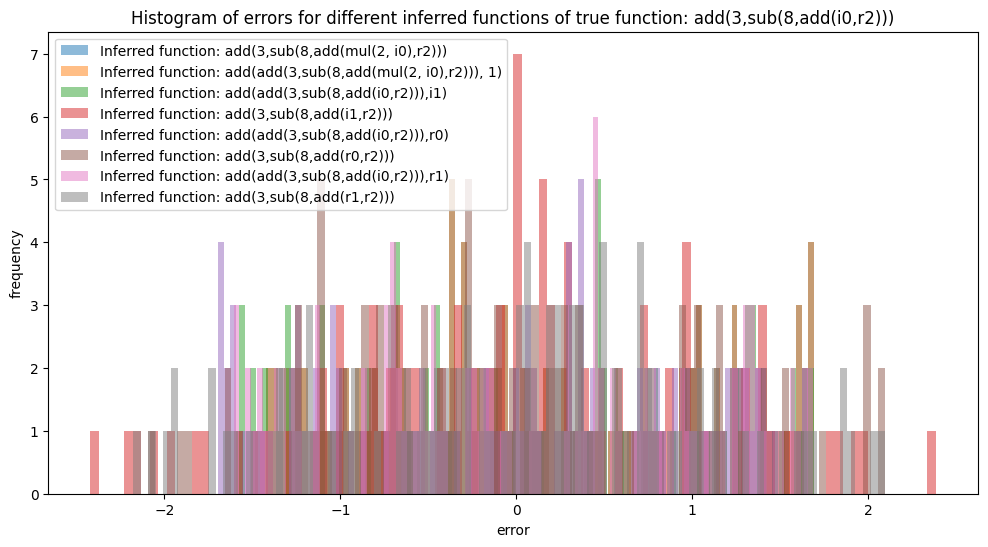

In [14]:
#Histogram of errors for different inferred functions

plt.figure(figsize=(12, 6))
for func in fakeFunctions:
    error = testOuts[func] - trueOut
    error = error - np.mean(error)
    if np.std(error) != 0:
        error = error / np.std(error)
        plt.hist(error, bins=100, alpha=0.5, label=f'Inferred function: {func}')
plt.title(f'Histogram of errors for different inferred functions of true function: {trueFunction}')
plt.xlabel('error')
plt.ylabel('frequency')
plt.legend()
plt.show()
